<a href="https://colab.research.google.com/github/jasunny28/BanglaScript_compiler/blob/main/TB_Detection_Using_Cough_Audio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive/TB_Project/dataset')

['archive.zip']

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/TB_Project/dataset/archive.zip'

extract_path = '/content/TB_Dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os
# dataset structure
for root, dirs, files in os.walk('/content/TB_Dataset'):
    level = root.replace('/content/TB_Dataset', '').count(os.sep)
    indent = ' ' * 4 * level
    print(f'{indent}{os.path.basename(root)}/')

    for file in files[:5]:
        print(f'{indent}    {file}')

TB_Dataset/
    Kaggle_RespiScan_Dataset/
        metadata_kaggle.csv
        cwt_scalograms/
            train/
                TB/
                    PID_35A_16_pixel_0_clean.png
                    PID_71A_15_codec_clean.png
                    PID_211A_10_pixel_clean.png
                    PID_180A_29_codec_noisy.png
                    PID_208A_36_pixel_clean.png
                Healthy/
                    PID_11C_3_pixel_0_clean.png
                    PID_13C_106_pixel_0_clean.png
                    SCAL_FAST_PID_30C_127_codec.png
                    COSWARA_VrBIdIVnQkPbR9D2Gi7WCb17ST62_cough-shallow_noisy.png
                    SCAL_FAST_PID_34C_27_pixel_3.png
            test/
                TB/
                    PID_14A_142_codec_0_clean.png
                    PID_80A_18_codec_clean.png
                    PID_88A_100_codec_clean.png
                    PID_80A8_yeti_clean.png
                    PID_8A_7_pixel_0_clean.png
                Healthy/
                   

In [ ]:
import os

for root, dirs, files in os.walk('/content/TB_Dataset'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/TB_Dataset/Kaggle_RespiScan_Dataset/metadata_kaggle.csv


In [ ]:
import os

for root, dirs, files in os.walk('/content/TB_Dataset'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/TB_Dataset/Kaggle_RespiScan_Dataset/metadata_kaggle.csv


In [ ]:
import pandas as pd

csv_path = '/content/TB_Dataset/Kaggle_RespiScan_Dataset/metadata_kaggle.csv'

df = pd.read_csv(csv_path)

df.head()

,Unnamed: 0,subject,cohort,sub,Label,age,gndr_a,lab_sptm_xprt_rslt_a,lab_sptm_xpert_ct_a,lab_sptm_cx_rslt_a,...,transfer_from_A,cough_cause,cough_trt,Primary findings,Cavities - Y/N; if Y number of lobes,Number_of_quadrants_with_consolidation,Abnormal_quadrants_number_denominator_4,Permission_sound,split,source_dataset
0,0.0,PID_108A,A,108,TB,25.0,1.0,3.0,22.4,1.0,...,NaN,NaN,NaN,"LLL limited consolidation, RLL linear opacity,...",YES - 1,1,2.0,Yes,test,TBscreen
1,1.0,PID_10A,A,10,TB,39.0,0.0,2.0,29.8,1.0,...,NaN,NaN,NaN,"RUL (lobar consolidation), RLL (limited consol...",YES - 1,2,2.0,Yes,train,TBscreen
2,2.0,PID_10C,C,10,NTB,35.0,0.0,NaN,NaN,NaN,...,1.0,1.0,1.0,Normal lung fields,NaN,Normal lung fields,NaN,Yes,test,TBscreen
3,3.0,PID_4A,A,110,NTB,37.0,0.0,NaN,NaN,2.0,...,NaN,NaN,NaN,RUL/LUL/RLL/LLL infiltrates,NO,0,4.0,No,Excluded,TBscreen
4,4.0,PID_113A,A,113,TB,25.0,1.0,3.0,24.2,1.0,...,NaN,NaN,NaN,"RUL limited consolidatin, cavity",YES - 1,1,1.0,No,train,TBscreen


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (225, 41)


In [ ]:
print(df.columns.tolist())

['Unnamed: 0', 'subject', 'cohort', 'sub', 'Label', 'age', 'gndr_a', 'lab_sptm_xprt_rslt_a', 'lab_sptm_xpert_ct_a', 'lab_sptm_cx_rslt_a', 'lab_sptm_cx_ttd_a', 'lab_sptm_smr_rslt_a', 'cxr_findings_a___5', 'hiv_infected_a', 'smkr_a', 'class', 'single_device_cough_count', 'all_device_cough_count', 'fever', 'un_wght_loss', 'nght_swts', 'inhaler', 'extrapulmo_tb', 'cough', 'cough_drtn', 'cough_bld', 'comor_other', 'comor_lung', 'prev_tb', 'comor', 'cough_cause_other', 'transfer_from_A', 'cough_cause', 'cough_trt', 'Primary findings', 'Cavities - Y/N; if Y number of lobes', 'Number_of_quadrants_with_consolidation', 'Abnormal_quadrants_number_denominator_4', 'Permission_sound', 'split', 'source_dataset']


In [ ]:
label_counts = df['Label'].value_counts()

print("TB Count:", label_counts.get('TB', 0))
print("NTB Count:", label_counts.get('NTB', 0))

TB Count: 103
NTB Count: 122


In [ ]:
# Class percentage calculate
label_percentage = (df['Label'].value_counts(normalize=True) * 100)

print(label_percentage)

Label
NTB    54.222222
TB     45.777778
Name: proportion, dtype: float64


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'TB_Dataset', 'drive', 'sample_data']


In [ ]:
print(os.listdir("/content/TB_Dataset"))

['Kaggle_RespiScan_Dataset']


In [ ]:
print(os.listdir("/content/TB_Dataset/Kaggle_RespiScan_Dataset"))

['cwt_scalograms', 'metadata_kaggle.csv', 'audio_wav']


In [ ]:
import os

audio_folder = "/content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav"

# সব audio files দেখুন
audio_files = os.listdir(audio_folder)

print("Total audio files:", len(audio_files))

print("\nFirst 10 audio files:")
print(audio_files[:10])

Total audio files: 3

First 10 audio files:
['train', 'test', 'val']


In [ ]:
import os

audio_folder = "/content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav"

for split in ["train", "val", "test"]:
    split_path = os.path.join(audio_folder, split)

    files = os.listdir(split_path)

    print(f"{split.upper()} audio files: {len(files)}")
    print("First 5 files:", files[:5])
    print("-" * 50)

TRAIN audio files: 2
First 5 files: ['TB', 'Healthy']
--------------------------------------------------
VAL audio files: 2
First 5 files: ['TB', 'Healthy']
--------------------------------------------------
TEST audio files: 2
First 5 files: ['TB', 'Healthy']
--------------------------------------------------


In [ ]:
import os

audio_folder = "/content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav"

for split in ["train", "val", "test"]:

    print(f"\n{'='*40}")
    print(f"{split.upper()} DATA")
    print('='*40)

    split_path = os.path.join(audio_folder, split)

    for label in ["Healthy", "TB"]:
        label_path = os.path.join(split_path, label)

        files = [
            f for f in os.listdir(label_path)
            if f.lower().endswith((".wav", ".mp3", ".flac"))
        ]

        print(f"{label}: {len(files)} audio files")
        print("First 5:", files[:5])


TRAIN DATA
Healthy: 317 audio files
First 5: ['PID_77C_26_pixel.wav', 'COSWARA_1ctsxp37dWNbCbizTioZzpAWqJx2_cough-shallow.wav', 'PID_4C11_yeti_0.wav', 'COSWARA_TRK6gUseEUS7dbF0soG80W1uLm53_cough-shallow.wav', 'COSWARA_9XKj7fAmvwPUas9GFPZuTpev7T03_cough-shallow.wav']
TB: 522 audio files
First 5: ['PID_149A_23_pixel.wav', 'PID_93A_77_pixel.wav', 'PID_225A_15_pixel_0.wav', 'PID_228A_735_pixel.wav', 'PID_181A_22_pixel.wav']

VAL DATA
Healthy: 102 audio files
First 5: ['PID_32A_mvt_C_462_pixel.wav', 'PID_32A_mvt_C190_yeti.wav', 'PID_22C_42_pixel_2.wav', 'PID_15C_19_yeti_0.wav', 'PID_7C_13_codec_1.wav']
TB: 127 audio files
First 5: ['PID_76A103_yeti.wav', 'PID_13A_4_pixel_0.wav', 'PID_182A_220_pixel.wav', 'PID_182A_284_pixel.wav', 'PID_96A_36_yeti.wav']

TEST DATA
Healthy: 66 audio files
First 5: ['COSWARA_mFQ65xqfxpXiS6vwK1HKwq7j8o62_cough-shallow.wav', 'COSWARA_jRjAYMmAQee5uVm5fU8yVnpuvs33_cough-heavy.wav', 'COSWARA_l8qDG3sN6tczDZGHbgPje0suopx1_cough-shallow.wav', 'PID_10C_11_codec.wav', 

In [ ]:
import os

audio_folder = "/content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav"

summary = {}

for split in ["train", "val", "test"]:
    summary[split] = {}

    for label in ["Healthy", "TB"]:
        label_path = os.path.join(audio_folder, split, label)

        files = [
            f for f in os.listdir(label_path)
            if f.lower().endswith(".wav")
        ]

        summary[split][label] = len(files)

# Print summary
total_healthy = 0
total_tb = 0

for split in summary:
    healthy = summary[split]["Healthy"]
    tb = summary[split]["TB"]

    total_healthy += healthy
    total_tb += tb

    print(f"{split.upper()}")
    print(f"  Healthy: {healthy}")
    print(f"  TB: {tb}")
    print(f"  Total: {healthy + tb}")
    print()

print("=" * 30)
print("OVERALL DATASET")
print("=" * 30)
print("Total Healthy:", total_healthy)
print("Total TB:", total_tb)
print("Grand Total:", total_healthy + total_tb)


TRAIN
  Healthy: 317
  TB: 522
  Total: 839

VAL
  Healthy: 102
  TB: 127
  Total: 229

TEST
  Healthy: 66
  TB: 133
  Total: 199

OVERALL DATASET
Total Healthy: 485
Total TB: 782
Grand Total: 1267


In [ ]:
!pip install librosa soundfile noisereduce -q

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# একটি TB audio file select করি

tb_folder = "/content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav/train/TB"

tb_files = [
    f for f in os.listdir(tb_folder)
    if f.lower().endswith(".wav")
]

print("Total TB training files:", len(tb_files))

# প্রথম audio file
audio_file = os.path.join(tb_folder, tb_files[0])

print("Selected audio file:")
print(audio_file)

Total TB training files: 522
Selected audio file:
/content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav/train/TB/PID_149A_23_pixel.wav


In [ ]:
# Audio load

y, sr = librosa.load(audio_file, sr=None)

print("Audio loaded successfully!")
print("Sample Rate:", sr, "Hz")
print("Number of Samples:", len(y))

duration = len(y) / sr
print("Duration:", round(duration, 2), "seconds")

Audio loaded successfully!
Sample Rate: 44100 Hz
Number of Samples: 44100
Duration: 1.0 seconds


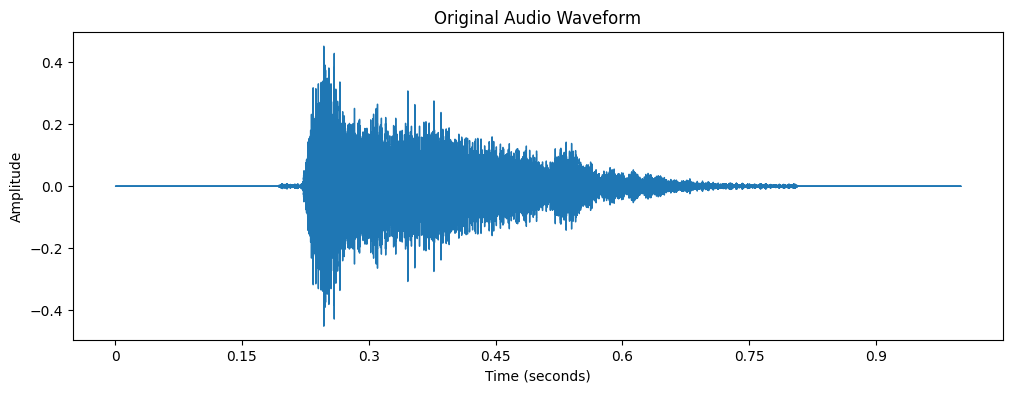

In [ ]:
# Original audio waveform

plt.figure(figsize=(12, 4))

librosa.display.waveshow(y, sr=sr)

plt.title("Original Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
# Silence trim

y_trimmed, index = librosa.effects.trim(
    y,
    top_db=30
)

print("Original samples:", len(y))
print("Trimmed samples:", len(y_trimmed))

# Duration comparison
original_duration = len(y) / sr
trimmed_duration = len(y_trimmed) / sr

print("\nOriginal duration:", round(original_duration, 4), "seconds")
print("Trimmed duration:", round(trimmed_duration, 4), "seconds")

Original samples: 44100
Trimmed samples: 23040

Original duration: 1.0 seconds
Trimmed duration: 0.5224 seconds


In [ ]:
# Noise reduction

import noisereduce as nr

y_denoised = nr.reduce_noise(
    y=y_trimmed,
    sr=sr
)

print("Noise reduction completed successfully!")
print("Original trimmed samples:", len(y_trimmed))
print("Denoised samples:", len(y_denoised))

Noise reduction completed successfully!
Original trimmed samples: 23040
Denoised samples: 23040


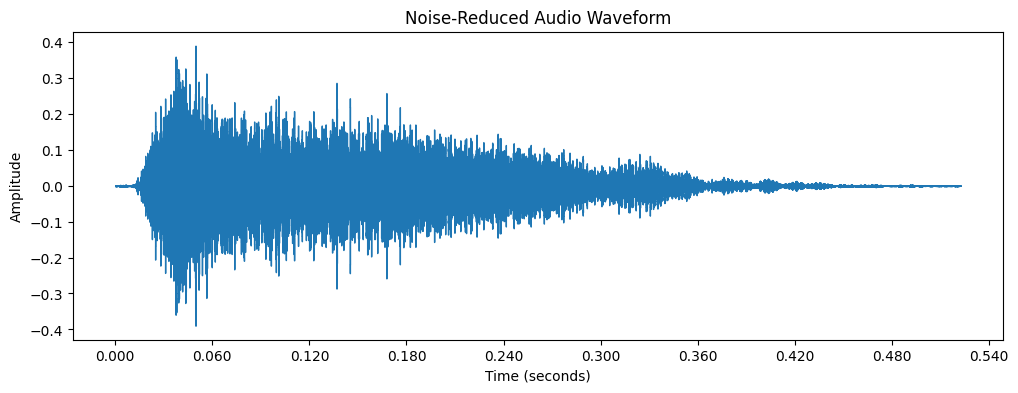

In [ ]:
# Noise-reduced audio waveform

plt.figure(figsize=(12, 4))

librosa.display.waveshow(y_denoised, sr=sr)

plt.title("Noise-Reduced Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
# Audio normalization

y_normalized = librosa.util.normalize(y_denoised)

print("Audio normalization completed successfully!")
print("Maximum amplitude:", np.max(np.abs(y_normalized)))
print("Normalized samples:", len(y_normalized))

Audio normalization completed successfully!
Maximum amplitude: 1.0
Normalized samples: 23040


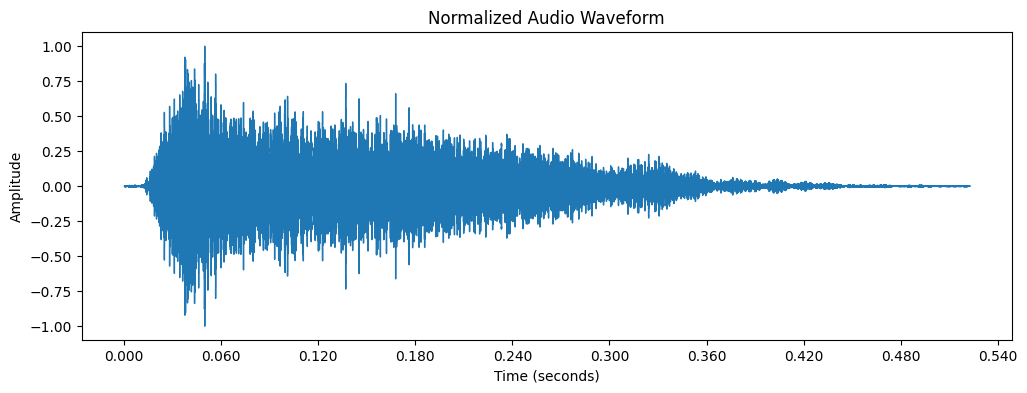

In [ ]:
# Normalized audio waveform

plt.figure(figsize=(12, 4))

librosa.display.waveshow(y_normalized, sr=sr)

plt.title("Normalized Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [ ]:
# MFCC Feature Extraction

n_mfcc = 40

mfcc = librosa.feature.mfcc(
    y=y_normalized,
    sr=sr,
    n_mfcc=n_mfcc
)

print("MFCC extracted successfully!")
print("MFCC shape:", mfcc.shape)
print("Number of MFCC coefficients:", mfcc.shape[0])
print("Number of time frames:", mfcc.shape[1])

MFCC extracted successfully!
MFCC shape: (40, 46)
Number of MFCC coefficients: 40
Number of time frames: 46


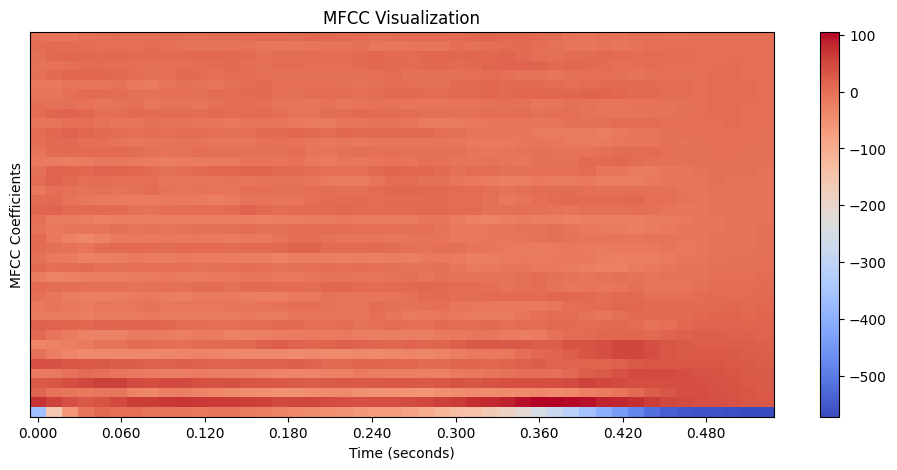

In [ ]:
# MFCC Visualization

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sr
)

plt.colorbar()
plt.title("MFCC Visualization")
plt.xlabel("Time (seconds)")
plt.ylabel("MFCC Coefficients")

plt.show()

In [ ]:
# Mel-Spectrogram Feature Extraction

mel_spec = librosa.feature.melspectrogram(
    y=y_normalized,
    sr=sr,
    n_mels=128
)

# Convert to decibel (dB)
mel_spec_db = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

print("Mel-Spectrogram extracted successfully!")
print("Mel-Spectrogram shape:", mel_spec.shape)

Mel-Spectrogram extracted successfully!
Mel-Spectrogram shape: (128, 46)


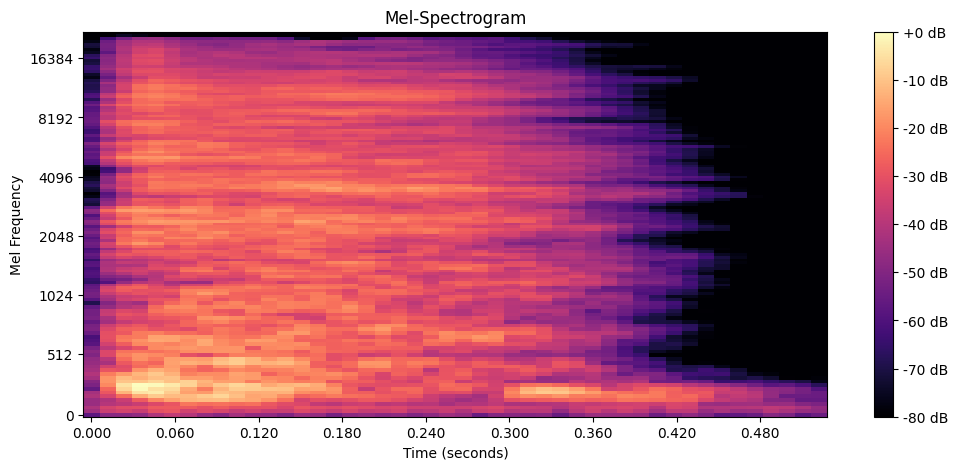

In [ ]:
# Mel-Spectrogram Visualization

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    mel_spec_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("Mel Frequency")

plt.show()

In [ ]:
# CQT Feature Extraction

cqt = librosa.cqt(
    y_normalized,
    sr=sr
)

# Convert magnitude to dB
cqt_db = librosa.amplitude_to_db(
    np.abs(cqt),
    ref=np.max
)

print("CQT extracted successfully!")
print("CQT shape:", cqt.shape)

CQT extracted successfully!
CQT shape: (84, 46)


/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=256 is too large for input signal of length=180
  warnings.warn(


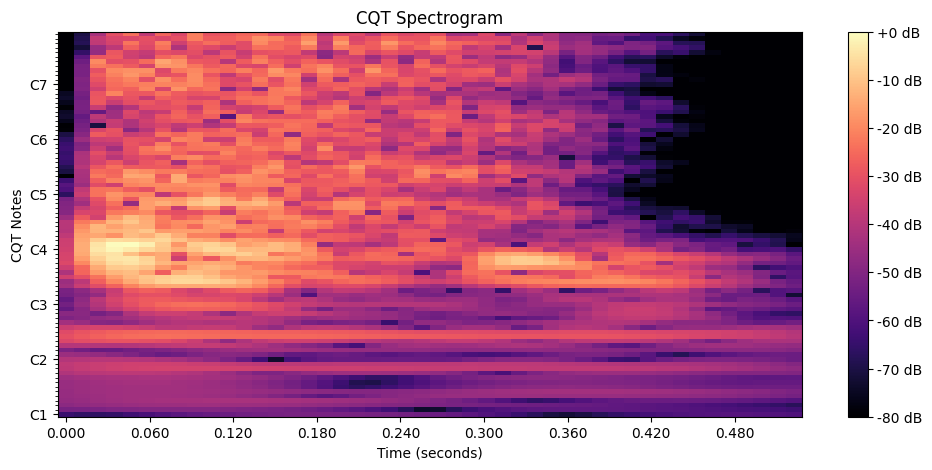

In [ ]:
# CQT Visualization

plt.figure(figsize=(12, 5))

librosa.display.specshow(
    cqt_db,
    sr=sr,
    x_axis="time",
    y_axis="cqt_note"
)

plt.colorbar(format="%+2.0f dB")
plt.title("CQT Spectrogram")
plt.xlabel("Time (seconds)")
plt.ylabel("CQT Notes")

plt.show()

In [ ]:
# Create file paths and labels for the whole dataset

healthy_folder = "/content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav/train/Healthy"
tb_folder = "/content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav/train/TB"

file_paths = []
labels = []

# Healthy files
for file in os.listdir(healthy_folder):
    if file.lower().endswith(".wav"):
        file_paths.append(os.path.join(healthy_folder, file))
        labels.append(0)  # Healthy = 0

# TB files
for file in os.listdir(tb_folder):
    if file.lower().endswith(".wav"):
        file_paths.append(os.path.join(tb_folder, file))
        labels.append(1)  # TB = 1

print("Total audio files:", len(file_paths))
print("Healthy files:", labels.count(0))
print("TB files:", labels.count(1))

Total audio files: 839
Healthy files: 317
TB files: 522


In [ ]:
# Feature extraction function

import numpy as np
import librosa
from tqdm import tqdm

def extract_mfcc(file_path, n_mfcc=40, max_frames=50):

    try:
        # Load audio
        y, sr = librosa.load(file_path, sr=None)

        # Silence trimming
        y, _ = librosa.effects.trim(y, top_db=30)

        # Normalize audio
        y = librosa.util.normalize(y)

        # Extract MFCC
        mfcc = librosa.feature.mfcc(
            y=y,
            sr=sr,
            n_mfcc=n_mfcc
        )

        # Make all features same size
        if mfcc.shape[1] < max_frames:
            pad_width = max_frames - mfcc.shape[1]

            mfcc = np.pad(
                mfcc,
                pad_width=((0, 0), (0, pad_width)),
                mode='constant'
            )

        else:
            mfcc = mfcc[:, :max_frames]

        return mfcc

    except Exception as e:
        print("Error processing:", file_path)
        return None

In [ ]:
X = []
y = []

print("Extracting features...")

for file_path, label in tqdm(zip(file_paths, labels),
                             total=len(file_paths)):

    feature = extract_mfcc(file_path)

    if feature is not None:
        X.append(feature)
        y.append(label)

# Convert to numpy array
X = np.array(X)
y = np.array(y)

print("\nFeature extraction completed!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Extracting features...


  1%|          | 5/839 [00:00<00:17, 48.85it/s]

Error processing: /content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav/train/Healthy/COSWARA_TRK6gUseEUS7dbF0soG80W1uLm53_cough-shallow.wav
Error processing: /content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav/train/Healthy/COSWARA_9XKj7fAmvwPUas9GFPZuTpev7T03_cough-shallow.wav


 23%|██▎       | 197/839 [00:04<00:17, 35.83it/s]

Error processing: /content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav/train/Healthy/COSWARA_TRK6gUseEUS7dbF0soG80W1uLm53_cough-heavy.wav


 26%|██▋       | 221/839 [00:06<00:32, 18.94it/s]

Error processing: /content/TB_Dataset/Kaggle_RespiScan_Dataset/audio_wav/train/Healthy/COSWARA_9XKj7fAmvwPUas9GFPZuTpev7T03_cough-heavy.wav


100%|██████████| 839/839 [00:16<00:00, 50.13it/s]


Feature extraction completed!
X shape: (835, 40, 50)
y shape: (835,)


In [ ]:
print("Healthy (0):", np.sum(y == 0))
print("TB (1):", np.sum(y == 1))

Healthy (0): 313
TB (1): 522


In [ ]:
X = X[..., np.newaxis]

print("New X shape:", X.shape)

New X shape: (835, 40, 50, 1)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining Healthy:", np.sum(y_train == 0))
print("Training TB:", np.sum(y_train == 1))

print("\nTesting Healthy:", np.sum(y_test == 0))
print("Testing TB:", np.sum(y_test == 1))

X_train shape: (668, 40, 50, 1)
X_test shape: (167, 40, 50, 1)

Training Healthy: 250
Training TB: 418

Testing Healthy: 63
Testing TB: 104


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    # First CNN Layer
    Conv2D(
        32,
        (3, 3),
        activation='relu',
        input_shape=(40, 50, 1)
    ),

    MaxPooling2D(pool_size=(2, 2)),

    # Second CNN Layer
    Conv2D(
        64,
        (3, 3),
        activation='relu'
    ),

    MaxPooling2D(pool_size=(2, 2)),

    # Convert to 1D
    Flatten(),

    # Fully Connected Layer
    Dense(
        128,
        activation='relu'
    ),

    # Prevent Overfitting
    Dropout(0.5),

    # Output Layer
    Dense(
        1,
        activation='sigmoid'
    )
])

print("CNN Model created successfully!")

model.summary()

CNN Model created successfully!


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5632)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       721,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739,969 (2.82 MB)

 Trainable params: 739,969 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.5913 - loss: 3.5084 - val_accuracy: 0.7006 - val_loss: 0.6398
Epoch 2/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.6856 - loss: 0.6817 - val_accuracy: 0.7305 - val_loss: 0.5798
Epoch 3/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7395 - loss: 0.5977 - val_accuracy: 0.7246 - val_loss: 0.5568
Epoch 4/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7560 - loss: 0.5475 - val_accuracy: 0.7665 - val_loss: 0.5221
Epoch 5/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.7784 - loss: 0.5111 - val_accuracy: 0.7605 - val_loss: 0.5190
Epoch 6/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.8054 - loss: 0.4221 - val_accuracy: 0.7725 - val_loss: 0.4959
Epoch 7/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.8428 - loss: 0.4085 - val_accuracy: 0.7784 - val_loss: 0.5036
Epoch 8/20
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8353 - loss: 0.3525 - val_accuracy: 0.7485 - v

In [ ]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.622890055179596
Test Accuracy: 0.8143712282180786


In [ ]:
# Predictions

y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Prediction completed!")

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Prediction completed!


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Healthy", "TB"]
))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8143712574850299

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.80      0.68      0.74        63
          TB       0.82      0.89      0.86       104

    accuracy                           0.81       167
   macro avg       0.81      0.79      0.80       167
weighted avg       0.81      0.81      0.81       167


Confusion Matrix:
[[43 20]
 [11 93]]


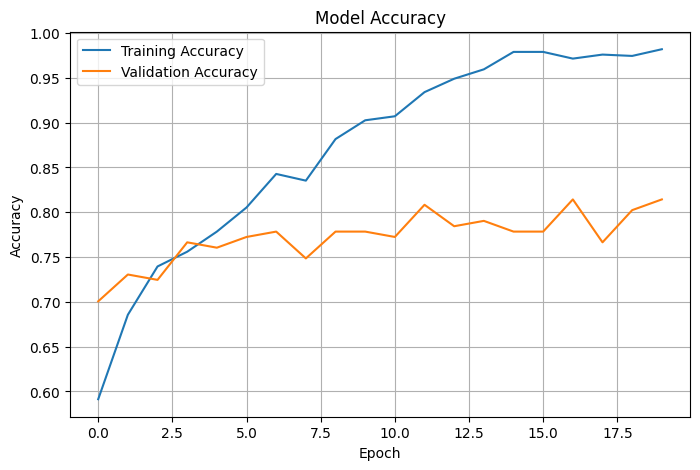

In [ ]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()

plt.show()

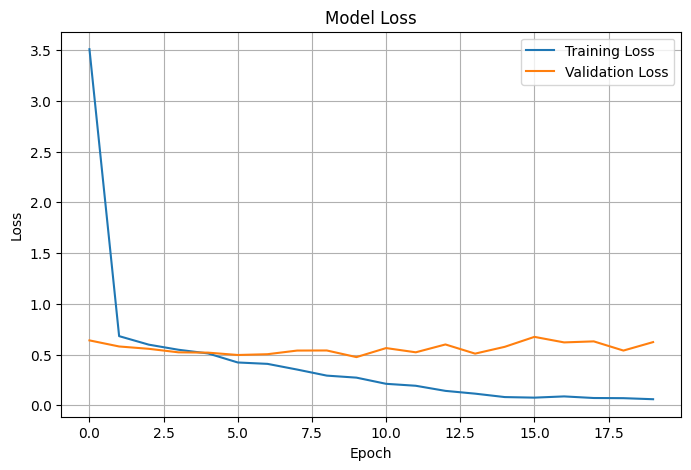

In [ ]:
# Loss graph
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()

plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Reduce learning rate if validation loss stops improving
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

print("Callbacks created successfully!")

Callbacks created successfully!


In [ ]:
from sklearn.model_selection import train_test_split

X_train_new, X_val, y_train_new, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.15,
    random_state=42,
    stratify=y_train
)

print("New Training shape:", X_train_new.shape)
print("Validation shape:", X_val.shape)

New Training shape: (567, 40, 50, 1)
Validation shape: (101, 40, 50, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout,
    Flatten,
    Dense,
    Input
)

improved_model = Sequential([

    Input(shape=(40, 50, 1)),

    # CNN Block 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # CNN Block 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    # CNN Block 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.30),

    # Classification
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.50),

    Dense(1, activation='sigmoid')
])

improved_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Improved CNN model created successfully!")

improved_model.summary()

Improved CNN model created successfully!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 40, 50, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 5, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3840)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       491,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 585,345 (2.23 MB)

 Trainable params: 584,897 (2.23 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print("Class Weights:", class_weights)

Class Weights: {np.int64(0): np.float64(1.336), np.int64(1): np.float64(0.7990430622009569)}


In [ ]:
history_improved = improved_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.4775 - loss: 1.8126 - val_accuracy: 0.4328 - val_loss: 1.0355
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step - accuracy: 0.6086 - loss: 0.6507 - val_accuracy: 0.4328 - val_loss: 0.8978
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.6629 - loss: 0.6218 - val_accuracy: 0.4328 - val_loss: 0.9518
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.6704 - loss: 0.6200 - val_accuracy: 0.4478 - val_loss: 0.8430
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.7303 - loss: 0.5772 - val_accuracy: 0.4478 - val_loss: 0.8423
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 119ms/step - accuracy: 0.7004 - loss: 0.6028 - val_accuracy: 0.5970 - val_loss: 0.6445
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 141ms/step - accuracy: 0.7172 - loss: 0.5807 - val_accuracy: 0.5597 - val_loss: 0.6701
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - accuracy: 0.7116 - loss: 0.5716 - val_accuracy: 0.

In [ ]:
# Evaluate Improved CNN

improved_loss, improved_accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Improved CNN Test Loss:", improved_loss)
print("Improved CNN Test Accuracy:", improved_accuracy)

Improved CNN Test Loss: 0.38787370920181274
Improved CNN Test Accuracy: 0.802395224571228


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Classification Report:

              precision    recall  f1-score   support

     Healthy       0.80      0.63      0.71        63
          TB       0.80      0.90      0.85       104

    accuracy                           0.80       167
   macro avg       0.80      0.77      0.78       167
weighted avg       0.80      0.80      0.80       167

Confusion Matrix:

[[40 23]
 [10 94]]


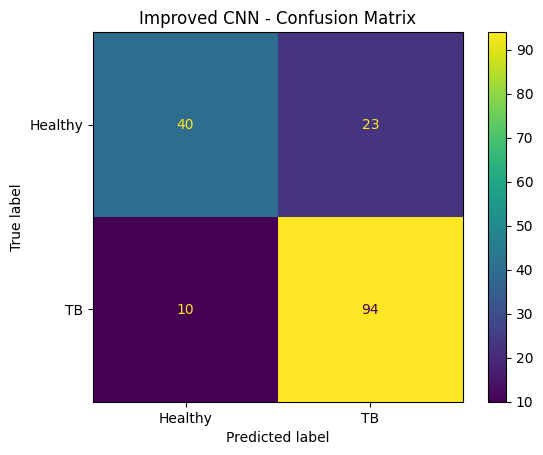

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Model prediction
y_pred_prob = improved_model.predict(X_test)

# Convert probability to class (0 or 1)
y_pred = (y_pred_prob >= 0.5).astype(int).flatten()

# True labels
y_true = np.array(y_test).flatten()

# Classification Report
print("Classification Report:\n")
print(classification_report(
    y_true,
    y_pred,
    target_names=["Healthy", "TB"]
))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n")
print(cm)

# Plot Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Healthy", "TB"]
)

disp.plot()
plt.title("Improved CNN - Confusion Matrix")
plt.show()

In [ ]:
# Confusion Matrix values
TN, FP, FN, TP = cm.ravel()

# Sensitivity (Recall for TB)
sensitivity = TP / (TP + FN)

# Specificity
specificity = TN / (TN + FP)

print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

print("\nSensitivity:", sensitivity)
print("Specificity:", specificity)

True Negative (TN): 40
False Positive (FP): 23
False Negative (FN): 10
True Positive (TP): 94

Sensitivity: 0.9038461538461539
Specificity: 0.6349206349206349


AUC Score: 0.8997252747252747


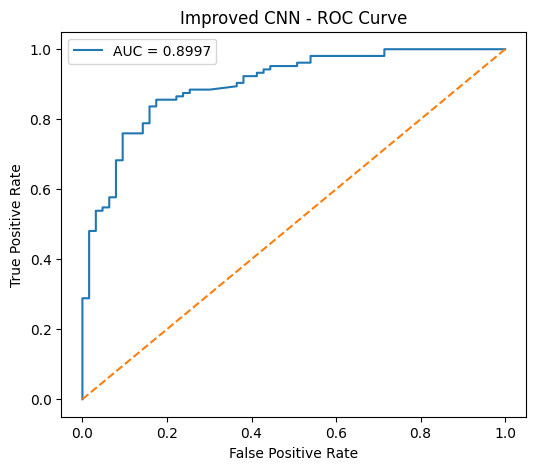

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)

# AUC score
roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Improved CNN - ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Try different thresholds

threshold_list = [0.5, 0.55, 0.6, 0.65, 0.7]

for threshold in threshold_list:

    y_pred_new = (y_pred_prob >= threshold).astype(int).flatten()

    cm_new = confusion_matrix(y_true, y_pred_new)
    TN, FP, FN, TP = cm_new.ravel()

    sensitivity_new = TP / (TP + FN)
    specificity_new = TN / (TN + FP)
    accuracy_new = (TP + TN) / (TP + TN + FP + FN)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy_new:.4f}")
    print(f"Sensitivity: {sensitivity_new:.4f}")
    print(f"Specificity: {specificity_new:.4f}")


Threshold: 0.5
Accuracy: 0.8024
Sensitivity: 0.9038
Specificity: 0.6349

Threshold: 0.55
Accuracy: 0.8323
Sensitivity: 0.8750
Specificity: 0.7619

Threshold: 0.6
Accuracy: 0.8443
Sensitivity: 0.8558
Specificity: 0.8254

Threshold: 0.65
Accuracy: 0.8383
Sensitivity: 0.8365
Specificity: 0.8413

Threshold: 0.7
Accuracy: 0.8084
Sensitivity: 0.7885
Specificity: 0.8413


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Model

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (668, 40, 50, 1)
X_test shape: (167, 40, 50, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization,
    Dropout, Reshape, Bidirectional, LSTM,
    Dense, GlobalAveragePooling1D
)

# CNN + BiLSTM Model
cnn_bilstm_model = Sequential([

    # CNN Feature Extraction
    Conv2D(32, (3, 3), activation='relu', padding='same',
           input_shape=(40, 50, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Dropout(0.3),

    # Convert CNN output to sequence for Bi-LSTM
    Reshape((10, 12 * 64)),

    # Bi-LSTM
    Bidirectional(LSTM(64, return_sequences=True)),

    # Pooling
    GlobalAveragePooling1D(),

    # Classification
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

cnn_bilstm_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_bilstm_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 40, 50, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 40, 50, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 20, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 20, 25, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 10, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 10, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 768)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 10, 128)        │       426,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 454,017 (1.73 MB)

 Trainable params: 453,825 (1.73 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

improved_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_bilstm = improved_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.8801 - loss: 0.2533 - val_accuracy: 0.7985 - val_loss: 0.4726
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 156ms/step - accuracy: 0.8764 - loss: 0.2611 - val_accuracy: 0.7836 - val_loss: 0.5408
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9082 - loss: 0.2321 - val_accuracy: 0.7910 - val_loss: 0.6422
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9195 - loss: 0.2260 - val_accuracy: 0.7910 - val_loss: 0.4832
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.9026 - loss: 0.1981 - val_accuracy: 0.7985 - val_loss: 0.4928
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.9270 - loss: 0.1898 - val_accuracy: 0.8060 - val_loss: 0.5099
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 178ms/step - accuracy: 0.9064 - loss: 0.2167 - val_accuracy: 0.7985 - val_loss: 0.5171
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - accuracy: 0.9307 - loss: 0.1886 - val_accuracy: 0.

In [ ]:
# Evaluate CNN + BiLSTM Model

bilstm_loss, bilstm_accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("CNN + BiLSTM Test Loss:", bilstm_loss)
print("CNN + BiLSTM Test Accuracy:", bilstm_accuracy)

CNN + BiLSTM Test Loss: 0.9109386801719666
CNN + BiLSTM Test Accuracy: 0.8143712282180786


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Classification Report:

              precision    recall  f1-score   support

     Healthy       0.86      0.60      0.71        63
          TB       0.80      0.94      0.86       104

    accuracy                           0.81       167
   macro avg       0.83      0.77      0.79       167
weighted avg       0.82      0.81      0.81       167

Confusion Matrix:
[[38 25]
 [ 6 98]]


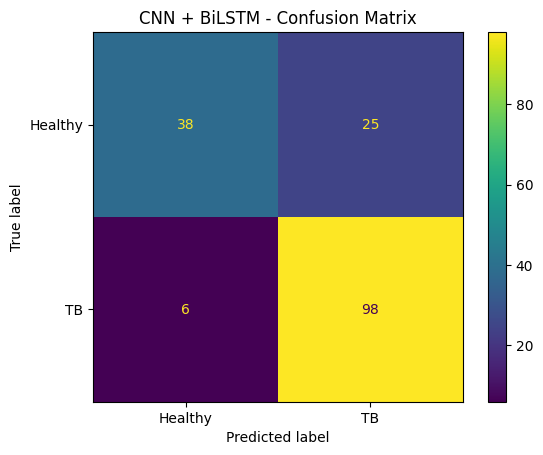

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Prediction probability
y_pred_prob_bilstm = improved_model.predict(X_test)

# Convert probability to class
y_pred_bilstm = (y_pred_prob_bilstm >= 0.45).astype(int).flatten()

# True labels
y_true_bilstm = np.array(y_test).flatten()

# Classification Report
print("Classification Report:\n")
print(classification_report(
    y_true_bilstm,
    y_pred_bilstm,
    target_names=["Healthy", "TB"]
))

# Confusion Matrix
cm_bilstm = confusion_matrix(y_true_bilstm, y_pred_bilstm)

print("Confusion Matrix:")
print(cm_bilstm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_bilstm,
    display_labels=["Healthy", "TB"]
)
disp.plot()
plt.title("CNN + BiLSTM - Confusion Matrix")
plt.show()

In [ ]:
# Sensitivity and Specificity for CNN + BiLSTM

TN, FP, FN, TP = cm_bilstm.ravel()

sensitivity_bilstm = TP / (TP + FN)
specificity_bilstm = TN / (TN + FP)

print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

print("\nSensitivity:", sensitivity_bilstm)
print("Specificity:", specificity_bilstm)

True Negative (TN): 38
False Positive (FP): 25
False Negative (FN): 6
True Positive (TP): 98

Sensitivity: 0.9423076923076923
Specificity: 0.6031746031746031


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
CNN + BiLSTM AUC Score: 0.8951465201465202


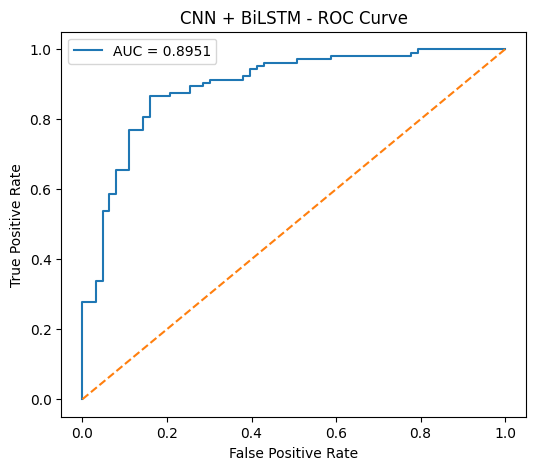

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predicted probabilities
y_pred_prob_bilstm = improved_model.predict(X_test)

# Flatten
y_pred_prob_bilstm = y_pred_prob_bilstm.flatten()

# ROC Curve
fpr, tpr, thresholds = roc_curve(
    y_test.flatten(),
    y_pred_prob_bilstm
)

# AUC Score
roc_auc_bilstm = auc(fpr, tpr)

print("CNN + BiLSTM AUC Score:", roc_auc_bilstm)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_bilstm:.4f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CNN + BiLSTM - ROC Curve")
plt.legend()
plt.show()

In [ ]:
# Try different thresholds for CNN + BiLSTM

threshold_list = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7]

for threshold in threshold_list:

    y_pred_new = (y_pred_prob_bilstm >= threshold).astype(int)

    cm_new = confusion_matrix(
        y_test.flatten(),
        y_pred_new
    )

    TN, FP, FN, TP = cm_new.ravel()

    sensitivity_new = TP / (TP + FN)
    specificity_new = TN / (TN + FP)
    accuracy_new = (TP + TN) / (TP + TN + FP + FN)

    print(f"\nThreshold: {threshold}")
    print(f"Accuracy: {accuracy_new:.4f}")
    print(f"Sensitivity: {sensitivity_new:.4f}")
    print(f"Specificity: {specificity_new:.4f}")


Threshold: 0.4
Accuracy: 0.8144
Sensitivity: 0.9423
Specificity: 0.6032

Threshold: 0.45
Accuracy: 0.8144
Sensitivity: 0.9423
Specificity: 0.6032

Threshold: 0.5
Accuracy: 0.8144
Sensitivity: 0.9423
Specificity: 0.6032

Threshold: 0.55
Accuracy: 0.8144
Sensitivity: 0.9423
Specificity: 0.6032

Threshold: 0.6
Accuracy: 0.8144
Sensitivity: 0.9423
Specificity: 0.6032

Threshold: 0.65
Accuracy: 0.8024
Sensitivity: 0.9231
Specificity: 0.6032

Threshold: 0.7
Accuracy: 0.8084
Sensitivity: 0.9231
Specificity: 0.6190


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Input
inputs = layers.Input(shape=X_train.shape[1:])

# CNN Part
x = layers.Conv2D(
    32, (3, 3),
    activation='relu',
    padding='same'
)(inputs)

x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(
    64, (3, 3),
    activation='relu',
    padding='same'
)(x)

x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Dropout(0.3)(x)

# Reshape for BiLSTM
# Current shape: (10, 12, 64)
x = layers.Reshape((10, 768))(x)

# BiLSTM
x = layers.Bidirectional(
    layers.LSTM(64, return_sequences=True)
)(x)

# Self-Attention
attention_output = layers.Attention()([x, x])

# Pooling
x = layers.GlobalAveragePooling1D()(attention_output)

# Dense Layers
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)

# Output
outputs = layers.Dense(1, activation='sigmoid')(x)

# Final Proposed Model
proposed_model = models.Model(
    inputs=inputs,
    outputs=outputs
)

# Model Summary
proposed_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 40, 50, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 40, 50,    │        320 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 50,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_7     │ (None, 20, 25,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 20, 25,    │     18,496 │ max_pooling2d_7[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 25,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 10, 12,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 10, 12,    │          0 │ max_pooling2d_8[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 10, 768)   │          0 │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 10, 128)   │    426,496 │ reshape_1[0][0]   │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 10, 128)   │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 64)        │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 1)         │         65 │ dropout_8[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 454,017 (1.73 MB)

 Trainable params: 453,825 (1.73 MB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

proposed_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Proposed Model Compiled Successfully!")

Proposed Model Compiled Successfully!


In [ ]:
# Train Proposed Model

history_proposed = proposed_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 7s 163ms/step - accuracy: 0.5581 - loss: 0.6800 - val_accuracy: 0.4328 - val_loss: 0.9042
Epoch 2/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.6798 - loss: 0.6274 - val_accuracy: 0.4328 - val_loss: 1.1839
Epoch 3/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.7172 - loss: 0.5906 - val_accuracy: 0.4328 - val_loss: 1.0281
Epoch 4/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.7360 - loss: 0.5573 - val_accuracy: 0.4403 - val_loss: 0.9130
Epoch 5/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.7397 - loss: 0.5237 - val_accuracy: 0.5075 - val_loss: 0.8533
Epoch 6/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - accuracy: 0.7865 - loss: 0.4836 - val_accuracy: 0.6866 - val_loss: 0.5934
Epoch 7/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.8109 - loss: 0.4542 - val_accuracy: 0.6418 - val_loss: 0.6424
Epoch 8/30
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.8127 - loss: 0.4115 - val_accuracy: 0.

In [ ]:
# Evaluate Proposed Model on Test Data

proposed_loss, proposed_accuracy = proposed_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Proposed Model Test Loss:", proposed_loss)
print("Proposed Model Test Accuracy:", proposed_accuracy)

Proposed Model Test Loss: 0.8893163800239563
Proposed Model Test Accuracy: 0.7904191613197327


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
Classification Report:

              precision    recall  f1-score   support

     Healthy       0.75      0.67      0.71        63
          TB       0.81      0.87      0.84       104

    accuracy                           0.79       167
   macro avg       0.78      0.77      0.77       167
weighted avg       0.79      0.79      0.79       167

Confusion Matrix:
[[42 21]
 [14 90]]


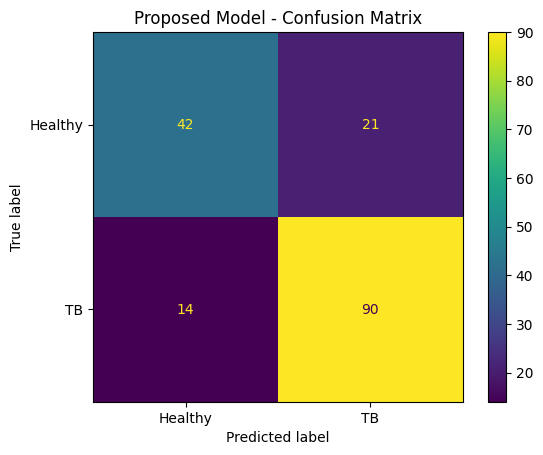

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred_prob = proposed_model.predict(X_test)

# Threshold = 0.45
threshold = 0.45
y_pred = (y_pred_prob >= threshold).astype(int).flatten()

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'TB']))

# Confusion Matrix
cm_proposed = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm_proposed)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_proposed,
    display_labels=['Healthy', 'TB']
)

disp.plot(cmap='viridis')
plt.title("Proposed Model - Confusion Matrix")
plt.show()

In [ ]:
# Sensitivity and Specificity for Proposed Model

TN, FP, FN, TP = cm_proposed.ravel()

sensitivity_proposed = TP / (TP + FN)
specificity_proposed = TN / (TN + FP)

print("True Negative (TN):", TN)
print("False Positive (FP):", FP)
print("False Negative (FN):", FN)
print("True Positive (TP):", TP)

print("\nSensitivity:", sensitivity_proposed)
print("Specificity:", specificity_proposed)

True Negative (TN): 42
False Positive (FP): 21
False Negative (FN): 14
True Positive (TP): 90

Sensitivity: 0.8653846153846154
Specificity: 0.6666666666666666


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Proposed Model AUC: 0.811965811965812


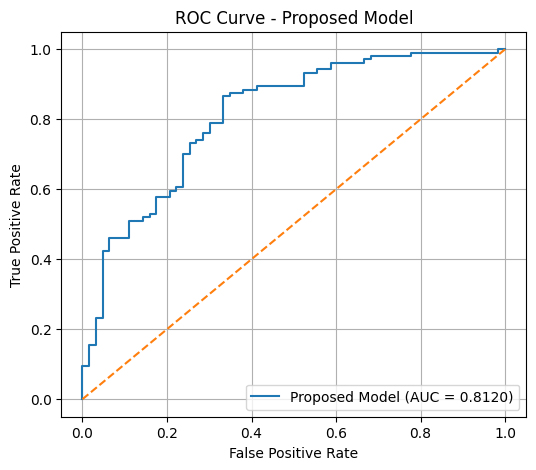

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predict probabilities
y_prob = proposed_model.predict(X_test)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
roc_auc = auc(fpr, tpr)

print("Proposed Model AUC:", roc_auc)

# Plot ROC Curve
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Proposed Model (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Proposed Model')
plt.legend()
plt.grid()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

# Predicted probabilities
y_prob = proposed_model.predict(X_test).ravel()

thresholds = np.arange(0.05, 0.96, 0.01)

results = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    TN, FP, FN, TP = confusion_matrix(y_test, y_pred).ravel()

    sensitivity = TP / (TP + FN)
    specificity = TN / (TN + FP)
    accuracy = accuracy_score(y_test, y_pred)

    gap = abs(sensitivity - specificity)
    youden_j = sensitivity + specificity - 1

    results.append([
        threshold,
        accuracy,
        sensitivity,
        specificity,
        gap,
        youden_j
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Threshold',
        'Accuracy',
        'Sensitivity',
        'Specificity',
        'Gap',
        'Youden_J'
    ]
)

# Sensitivity এবং Specificity সবচেয়ে কাছাকাছি
best_balanced = results_df.loc[results_df['Gap'].idxmin()]

print("BEST BALANCED THRESHOLD:")
print(best_balanced)

print("\nTop 10 thresholds with smallest gap:")
print(results_df.sort_values('Gap').head(10))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
BEST BALANCED THRESHOLD:
Threshold      0.900000
Accuracy       0.730539
Sensitivity    0.730769
Specificity    0.730159
Gap            0.000611
Youden_J       0.460928
Name: 85, dtype: float64

Top 10 thresholds with smallest gap:
    Threshold  Accuracy  Sensitivity  Specificity       Gap  Youden_J
85       0.90  0.730539     0.730769     0.730159  0.000611  0.460928
86       0.91  0.730539     0.721154     0.746032  0.024878  0.467186
87       0.92  0.730539     0.721154     0.746032  0.024878  0.467186
83       0.88  0.730539     0.740385     0.714286  0.026099  0.454670
82       0.87  0.730539     0.740385     0.714286  0.026099  0.454670
84       0.89  0.730539     0.740385     0.714286  0.026099  0.454670
88       0.93  0.724551     0.711538     0.746032  0.034493  0.457570
81       0.86  0.736527     0.750000     0.714286  0.035714  0.464286
80       0.85  0.742515     0.759615     0.714286  0.045330  0.473901
79       0.84  0.742515     0.

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Best Threshold: 0.92
Final Accuracy: 0.7305389221556886

Classification Report:
              precision    recall  f1-score   support

     Healthy       0.62      0.75      0.68        63
          TB       0.82      0.72      0.77       104

    accuracy                           0.73       167
   macro avg       0.72      0.73      0.72       167
weighted avg       0.75      0.73      0.73       167


Confusion Matrix:
[[47 16]
 [29 75]]


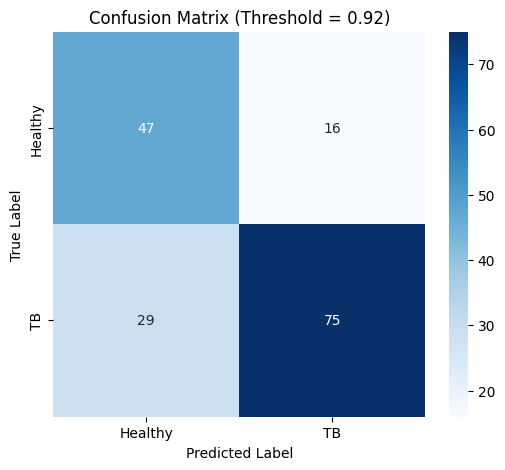

In [ ]:
# ==========================================
# Final Evaluation Using Best Threshold
# ==========================================

best_threshold = 0.92

# Probability prediction
y_prob = proposed_model.predict(X_test).ravel()

# Apply best threshold
y_pred_best = (y_prob >= best_threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Accuracy
final_accuracy = accuracy_score(y_test, y_pred_best)

print("Best Threshold:", best_threshold)
print("Final Accuracy:", final_accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=['Healthy', 'TB']
))

# Confusion Matrix
cm_best = confusion_matrix(y_test, y_pred_best)

print("\nConfusion Matrix:")
print(cm_best)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Healthy', 'TB'],
    yticklabels=['Healthy', 'TB']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix (Threshold = {best_threshold})')
plt.show()

In [ ]:
print("FINAL PROPOSED MODEL RESULTS")
print("=" * 35)
print("Best Threshold:", best_threshold)
print("Accuracy:", final_accuracy)
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)
print("AUC:", roc_auc)

FINAL PROPOSED MODEL RESULTS
Best Threshold: 0.92
Accuracy: 0.7305389221556886
Sensitivity: 0.6634615384615384
Specificity: 0.7619047619047619
AUC: 0.811965811965812


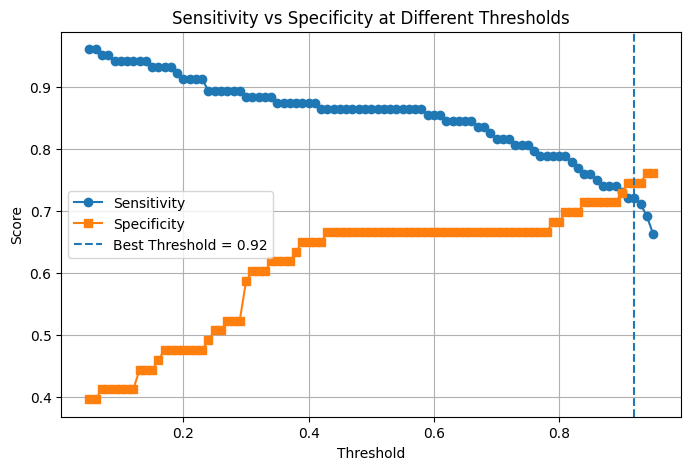

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    results_df['Threshold'],
    results_df['Sensitivity'],
    marker='o',
    label='Sensitivity'
)

plt.plot(
    results_df['Threshold'],
    results_df['Specificity'],
    marker='s',
    label='Specificity'
)

# Best threshold line
plt.axvline(
    best_threshold,
    linestyle='--',
    label=f'Best Threshold = {best_threshold}'
)

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Sensitivity vs Specificity at Different Thresholds')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

final_results = pd.DataFrame({
    'Model': ['Proposed Model'],
    'Best Threshold': [best_threshold],
    'Accuracy': [accuracy],
    'Sensitivity': [sensitivity],
    'Specificity': [specificity],
    'AUC': [roc_auc]
})

final_results

,Model,Best Threshold,Accuracy,Sensitivity,Specificity,AUC
0,Proposed Model,0.92,0.700599,0.663462,0.761905,0.811966


In [ ]:
# Save final results as CSV

final_results.to_csv('final_model_results.csv', index=False)

print("Results saved successfully!")

Results saved successfully!


In [ ]:
from google.colab import files

files.download('final_model_results.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

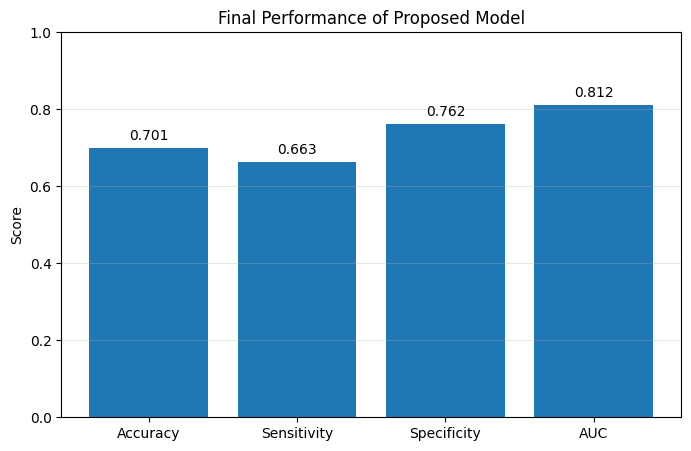

In [ ]:
import matplotlib.pyplot as plt

# Metrics
metrics = ['Accuracy', 'Sensitivity', 'Specificity', 'AUC']
values = [accuracy, sensitivity, specificity, roc_auc]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Final Performance of Proposed Model')

# Show values on bars
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# Check available trained models

for name, obj in globals().items():
    if hasattr(obj, 'layers') and hasattr(obj, 'predict'):
        print("MODEL FOUND:", name)

RuntimeError: dictionary changed size during iteration

In [ ]:
# ==========================================
# XAI STEP 1: Find a CNN-compatible model
# ==========================================

import tensorflow as tf

# Prefer proposed_model, otherwise improved_model
xai_model = None
xai_model_name = None

for name in ['proposed_model', 'improved_model', 'model']:
    if name in globals():
        candidate = globals()[name]

        # Check whether the model contains Conv2D
        has_conv2d = any(
            isinstance(layer, tf.keras.layers.Conv2D)
            for layer in candidate.layers
        )

        if has_conv2d:
            xai_model = candidate
            xai_model_name = name
            break

if xai_model is not None:
    print("XAI Model Selected:", xai_model_name)

    print("\nConv2D layers found:")
    for layer in xai_model.layers:
        if isinstance(layer, tf.keras.layers.Conv2D):
            print("-", layer.name)
else:
    print("No direct Conv2D model found.")
    print("We will inspect the model architecture before Grad-CAM.")

XAI Model Selected: proposed_model

Conv2D layers found:
- conv2d_7
- conv2d_8


In [ ]:
# ==========================================
# XAI STEP 2: Select last Conv2D layer
# ==========================================

last_conv_layer_name = None

for layer in reversed(xai_model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name
        break

print("Selected last Conv2D layer:", last_conv_layer_name)

Selected last Conv2D layer: conv2d_8


In [ ]:
# ==========================================
# XAI STEP 3: Create Grad-CAM Model
# ==========================================

grad_model = tf.keras.models.Model(
    inputs=xai_model.inputs,
    outputs=[
        xai_model.get_layer(last_conv_layer_name).output,
        xai_model.output
    ]
)

print("Grad-CAM model created successfully!")
print("Using Conv2D layer:", last_conv_layer_name)

Grad-CAM model created successfully!
Using Conv2D layer: conv2d_8


In [ ]:
# ==========================================
# XAI STEP 4: Calculate Gradients
# ==========================================

# Select one test sample
sample_index = 0

# Prepare sample
sample_input = X_test[sample_index:sample_index+1]

# Calculate gradients
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(sample_input)

    # Binary classification prediction
    class_channel = predictions[:, 0]

# Gradient of prediction with respect to Conv layer output
grads = tape.gradient(class_channel, conv_outputs)

print("Gradient calculation completed!")

print("Sample prediction probability:",
      float(predictions[0][0]))

print("Conv output shape:", conv_outputs.shape)
print("Gradient shape:", grads.shape)

/usr/local/lib/python3.13/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_40']
Received: inputs=Tensor(shape=(1, 40, 50, 1))
  warnings.warn(msg)


Gradient calculation completed!
Sample prediction probability: 0.9991897344589233
Conv output shape: (1, 20, 25, 64)
Gradient shape: (1, 20, 25, 64)


In [ ]:
# ==========================================
# XAI STEP 5: Generate Grad-CAM Heatmap
# ==========================================

# Average gradients over spatial dimensions
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Get convolution layer output for the sample
conv_outputs = conv_outputs[0]

# Multiply each feature map by its importance weight
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

# Remove last dimension
heatmap = tf.squeeze(heatmap)

# Convert negative values to zero
heatmap = tf.maximum(heatmap, 0)

# Normalize heatmap between 0 and 1
max_value = tf.reduce_max(heatmap)

if max_value != 0:
    heatmap = heatmap / max_value

# Convert to NumPy
heatmap = heatmap.numpy()

print("Grad-CAM heatmap generated successfully!")
print("Heatmap shape:", heatmap.shape)
print("Heatmap min:", heatmap.min())
print("Heatmap max:", heatmap.max())

Grad-CAM heatmap generated successfully!
Heatmap shape: (20, 25)
Heatmap min: 0.0
Heatmap max: 1.0


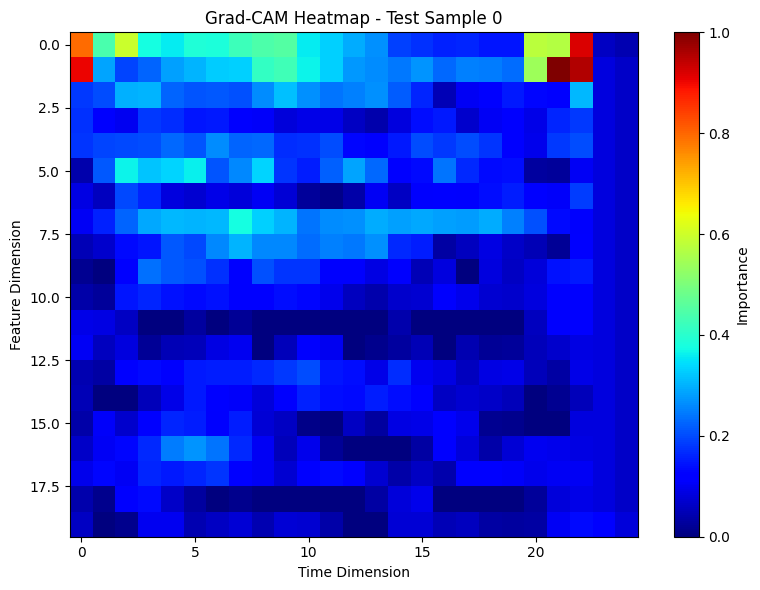

Grad-CAM heatmap visualization completed!


In [ ]:
# ==========================================
# XAI STEP 6: Visualize Grad-CAM Heatmap
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.imshow(
    heatmap,
    cmap='jet',
    aspect='auto'
)

plt.colorbar(label='Importance')

plt.title(
    f'Grad-CAM Heatmap - Test Sample {sample_index}'
)

plt.xlabel('Time Dimension')
plt.ylabel('Feature Dimension')

plt.tight_layout()
plt.show()

print("Grad-CAM heatmap visualization completed!")

Original heatmap shape: (20, 25)
Resized heatmap shape: (40, 50)


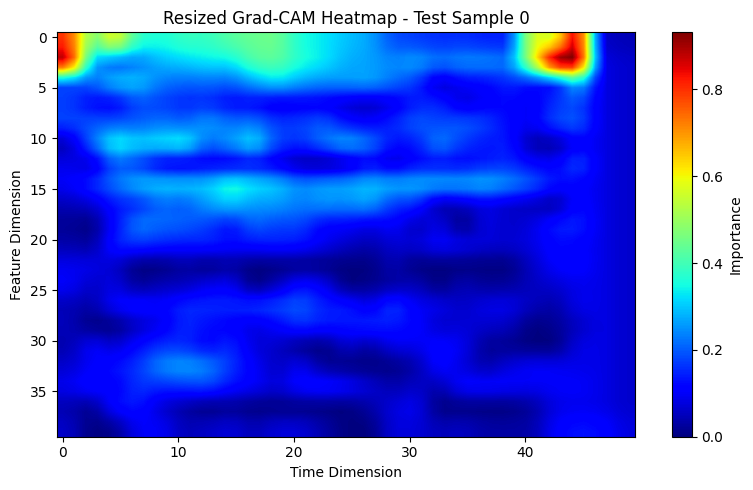

In [ ]:
# ==========================================
# XAI STEP 7: Resize Grad-CAM Heatmap
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt

# Get original input shape (without batch dimension)
input_height = sample_input.shape[1]
input_width = sample_input.shape[2]

# Resize heatmap to match input size
resized_heatmap = tf.image.resize(
    heatmap[..., tf.newaxis],
    (input_height, input_width)
)

# Remove last dimension
resized_heatmap = tf.squeeze(resized_heatmap).numpy()

print("Original heatmap shape:", heatmap.shape)
print("Resized heatmap shape:", resized_heatmap.shape)


# Visualize resized heatmap
plt.figure(figsize=(8, 5))

plt.imshow(
    resized_heatmap,
    cmap='jet',
    aspect='auto',
    interpolation='bilinear'
)

plt.colorbar(label='Importance')
plt.title(f'Resized Grad-CAM Heatmap - Test Sample {sample_index}')
plt.xlabel('Time Dimension')
plt.ylabel('Feature Dimension')

plt.tight_layout()
plt.show()

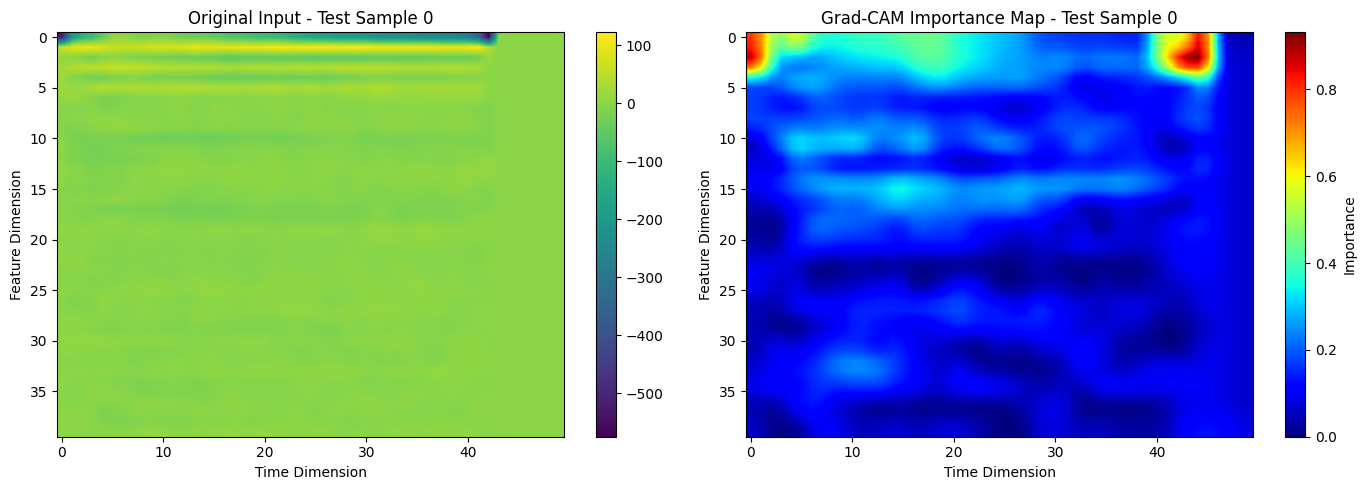

XAI comparison visualization completed!


In [ ]:
# ==========================================
# XAI STEP 8: Original Input vs Grad-CAM
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Remove batch dimension
original_input = sample_input[0]

# Remove channel dimension if it is 1
if original_input.shape[-1] == 1:
    original_input = original_input[..., 0]

# Create side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original input
im1 = axes[0].imshow(
    original_input,
    aspect='auto',
    interpolation='bilinear'
)

axes[0].set_title(
    f'Original Input - Test Sample {sample_index}'
)
axes[0].set_xlabel('Time Dimension')
axes[0].set_ylabel('Feature Dimension')

plt.colorbar(im1, ax=axes[0])

# Grad-CAM heatmap
im2 = axes[1].imshow(
    resized_heatmap,
    cmap='jet',
    aspect='auto',
    interpolation='bilinear'
)

axes[1].set_title(
    f'Grad-CAM Importance Map - Test Sample {sample_index}'
)
axes[1].set_xlabel('Time Dimension')
axes[1].set_ylabel('Feature Dimension')

plt.colorbar(im2, ax=axes[1], label='Importance')

plt.tight_layout()
plt.show()

print("XAI comparison visualization completed!")

In [ ]:
# ==========================================
# XAI STEP 9: Prediction and Label Analysis
# ==========================================

import numpy as np

# Get true label
true_label = y_test[sample_index]

# Handle possible array shape
true_label = np.squeeze(true_label)

# Get prediction probability
prediction_prob = float(xai_model.predict(sample_input, verbose=0)[0][0])

# Convert probability to predicted class
predicted_label = 1 if prediction_prob >= 0.5 else 0

# Change class names if your encoding is different
class_names = {
    0: "Healthy",
    1: "TB"
}

print("=" * 45)
print("XAI SAMPLE ANALYSIS")
print("=" * 45)

print("Sample Index        :", sample_index)
print("True Label          :", int(true_label),
      f"({class_names.get(int(true_label), 'Unknown')})")

print("Predicted Label     :", predicted_label,
      f"({class_names.get(predicted_label, 'Unknown')})")

print("Prediction Probability :", round(prediction_prob, 6))

print("=" * 45)

# Prediction correctness
if int(true_label) == predicted_label:
    print("Result: CORRECT PREDICTION")
else:
    print("Result: INCORRECT PREDICTION")

XAI SAMPLE ANALYSIS
Sample Index        : 0
True Label          : 1 (TB)
Predicted Label     : 1 (TB)
Prediction Probability : 0.99919
Result: CORRECT PREDICTION


In [ ]:
# ==========================================
# XAI STEP 10: Find Representative Samples
# ==========================================

import numpy as np

# Get predictions for all test samples
all_predictions = proposed_model.predict(X_test, verbose=0).flatten()

# Convert probabilities to class labels
all_predicted_labels = (all_predictions >= 0.5).astype(int)

# True labels
all_true_labels = np.squeeze(y_test).astype(int)

# Find different types of samples

# Correct TB prediction
correct_tb = np.where(
    (all_true_labels == 1) &
    (all_predicted_labels == 1)
)[0]

# Correct Healthy prediction
correct_healthy = np.where(
    (all_true_labels == 0) &
    (all_predicted_labels == 0)
)[0]

# Incorrect predictions
incorrect_samples = np.where(
    all_true_labels != all_predicted_labels
)[0]

print("Correct TB samples:", len(correct_tb))
print("Correct Healthy samples:", len(correct_healthy))
print("Incorrect samples:", len(incorrect_samples))

# Select representative samples
if len(correct_tb) > 0:
    tb_sample_index = correct_tb[0]
    print("\nSelected TB sample index:", tb_sample_index)

if len(correct_healthy) > 0:
    healthy_sample_index = correct_healthy[0]
    print("Selected Healthy sample index:", healthy_sample_index)

if len(incorrect_samples) > 0:
    incorrect_sample_index = incorrect_samples[0]
    print("Selected Incorrect sample index:", incorrect_sample_index)
else:
    print("\nNo incorrect predictions found in the test set.")

Correct TB samples: 90
Correct Healthy samples: 42
Incorrect samples: 35

Selected TB sample index: 0
Selected Healthy sample index: 1
Selected Incorrect sample index: 6


In [ ]:
# ==========================================
# XAI STEP 11: Reusable Grad-CAM Function
# ==========================================

import tensorflow as tf
import numpy as np

def generate_gradcam(model, input_sample, last_conv_layer_name):

    # Create Grad-CAM model
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    # Calculate gradients
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(input_sample)
        class_channel = predictions[:, 0]

    grads = tape.gradient(class_channel, conv_outputs)

    # Average gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Generate heatmap
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]

    # Remove last dimension
    heatmap = tf.squeeze(heatmap)

    # Remove negative values
    heatmap = tf.maximum(heatmap, 0)

    # Normalize
    max_value = tf.reduce_max(heatmap)

    if max_value > 0:
        heatmap = heatmap / max_value

    return heatmap.numpy(), predictions.numpy()[0][0]


print("Reusable Grad-CAM function created successfully!")

Reusable Grad-CAM function created successfully!


CORRECT TB SAMPLE - XAI ANALYSIS
Sample Index: 0
True Label: TB
Predicted Label: TB
Prediction Probability: 0.99919


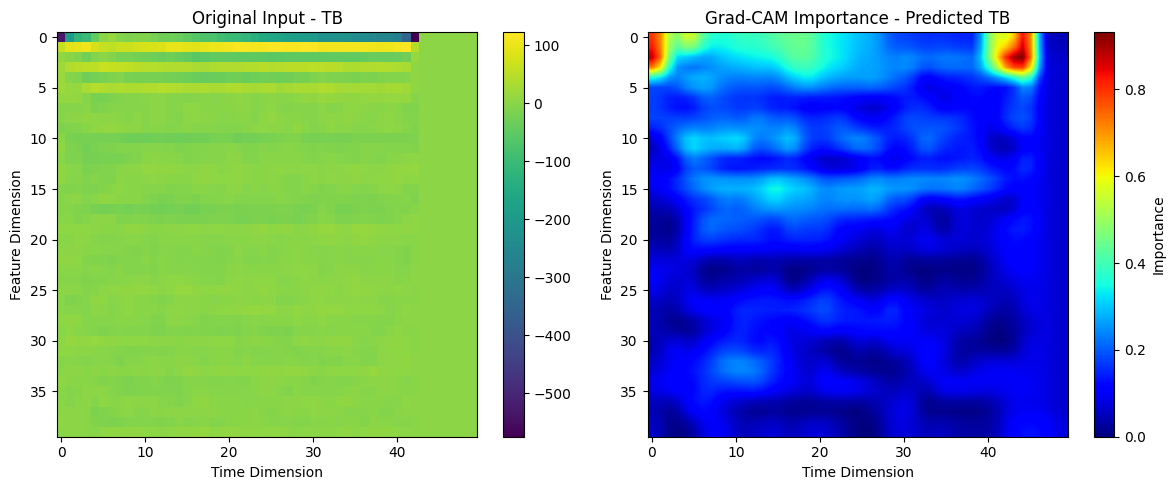

In [ ]:
# ==========================================
# XAI STEP 12: Analyze Correct TB Sample
# ==========================================

import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

# Select Correct TB sample
sample_index = tb_sample_index

# Prepare input
input_sample = X_test[sample_index:sample_index+1]

# Generate Grad-CAM
heatmap, prediction_prob = generate_gradcam(
    proposed_model,
    input_sample,
    last_conv_layer_name
)

# Resize heatmap to match input dimensions
input_height = input_sample.shape[1]
input_width = input_sample.shape[2]

resized_heatmap = tf.image.resize(
    heatmap[..., np.newaxis],
    (input_height, input_width)
)

resized_heatmap = tf.squeeze(resized_heatmap).numpy()

# Get true and predicted labels
true_label = int(np.squeeze(y_test[sample_index]))
predicted_label = 1 if prediction_prob >= 0.5 else 0

class_names = {
    0: "Healthy",
    1: "TB"
}

# Print analysis
print("=" * 50)
print("CORRECT TB SAMPLE - XAI ANALYSIS")
print("=" * 50)
print("Sample Index:", sample_index)
print("True Label:", class_names[true_label])
print("Predicted Label:", class_names[predicted_label])
print("Prediction Probability:", round(float(prediction_prob), 6))
print("=" * 50)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original input
im1 = axes[0].imshow(
    np.squeeze(input_sample),
    aspect="auto"
)

axes[0].set_title(
    f"Original Input - {class_names[true_label]}"
)

axes[0].set_xlabel("Time Dimension")
axes[0].set_ylabel("Feature Dimension")

plt.colorbar(im1, ax=axes[0])

# Grad-CAM
im2 = axes[1].imshow(
    resized_heatmap,
    cmap="jet",
    aspect="auto",
    interpolation="bilinear"
)

axes[1].set_title(
    f"Grad-CAM Importance - Predicted {class_names[predicted_label]}"
)

axes[1].set_xlabel("Time Dimension")
axes[1].set_ylabel("Feature Dimension")

plt.colorbar(im2, ax=axes[1], label="Importance")

plt.tight_layout()
plt.show()

Using XAI model: proposed_model
Input sample shape: (1, 40, 50, 1)
Model called successfully!
Detected last Conv layer: conv2d_8
CORRECT HEALTHY SAMPLE - XAI ANALYSIS
Sample Index: 1
True Label: Healthy
Predicted Label: Healthy
Prediction Probability: 0.0003


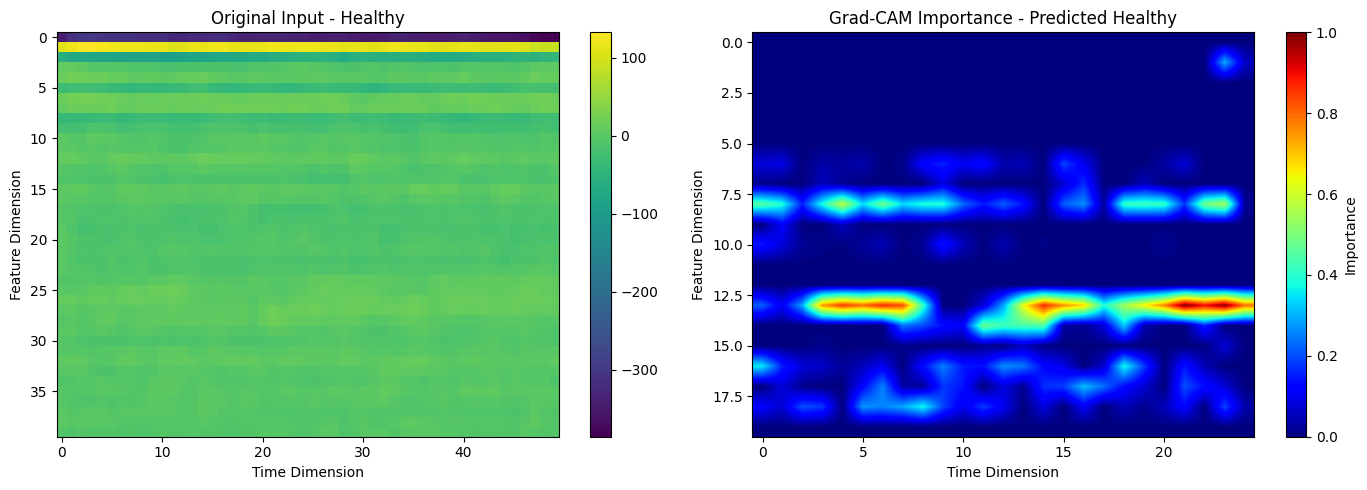

Correct Healthy Sample XAI completed successfully!


In [ ]:
# ==========================================
# XAI: CORRECT HEALTHY SAMPLE ANALYSIS
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt

# ------------------------------------------
# Use the CNN-compatible trained model
# ------------------------------------------

xai_model = proposed_model

print("Using XAI model:", "proposed_model")


# ------------------------------------------
# Select the correct Healthy sample
# ------------------------------------------

input_sample = X_test[
    healthy_sample_index:healthy_sample_index + 1
]

print("Input sample shape:", input_sample.shape)


# ------------------------------------------
# IMPORTANT: Call model once before Grad-CAM
# ------------------------------------------

_ = xai_model(input_sample, training=False)

print("Model called successfully!")


# ------------------------------------------
# Automatically find LAST Conv2D layer
# ------------------------------------------

conv_layers = [
    layer.name
    for layer in xai_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

if len(conv_layers) == 0:
    raise ValueError("No Conv2D layer found in proposed_model!")

last_conv_layer_name = conv_layers[-1]

print("Detected last Conv layer:", last_conv_layer_name)


# ------------------------------------------
# Generate Grad-CAM
# ------------------------------------------

heatmap, prediction_prob = generate_gradcam(
    xai_model,
    input_sample,
    last_conv_layer_name
)


# ------------------------------------------
# Convert prediction probability
# ------------------------------------------

prediction_prob = float(prediction_prob)

# Get predicted label
predicted_label = 1 if prediction_prob >= 0.5 else 0


# ------------------------------------------
# Print Information
# ------------------------------------------

print("=" * 45)
print("CORRECT HEALTHY SAMPLE - XAI ANALYSIS")
print("=" * 45)

print("Sample Index:", healthy_sample_index)
print("True Label:", class_names[0])
print("Predicted Label:", class_names[predicted_label])
print("Prediction Probability:", round(prediction_prob, 6))

print("=" * 45)


# ==========================================
# VISUALIZATION
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# ------------------------------------------
# Original Input
# ------------------------------------------

im1 = axes[0].imshow(
    input_sample[0].squeeze(),
    aspect='auto'
)

axes[0].set_title("Original Input - Healthy")
axes[0].set_xlabel("Time Dimension")
axes[0].set_ylabel("Feature Dimension")

plt.colorbar(im1, ax=axes[0])


# ------------------------------------------
# Grad-CAM Heatmap
# ------------------------------------------

im2 = axes[1].imshow(
    heatmap,
    cmap='jet',
    aspect='auto',
    interpolation='bilinear'
)

axes[1].set_title(
    f"Grad-CAM Importance - Predicted {class_names[predicted_label]}"
)

axes[1].set_xlabel("Time Dimension")
axes[1].set_ylabel("Feature Dimension")

plt.colorbar(
    im2,
    ax=axes[1],
    label="Importance"
)


plt.tight_layout()
plt.show()

print("Correct Healthy Sample XAI completed successfully!")

Using XAI model: proposed_model
Input sample shape: (1, 40, 50, 1)
Detected last Conv layer: conv2d_8
INCORRECT SAMPLE - XAI ANALYSIS
Sample Index: 6
True Label: TB
Predicted Label: Healthy
Prediction Probability: 0.015416


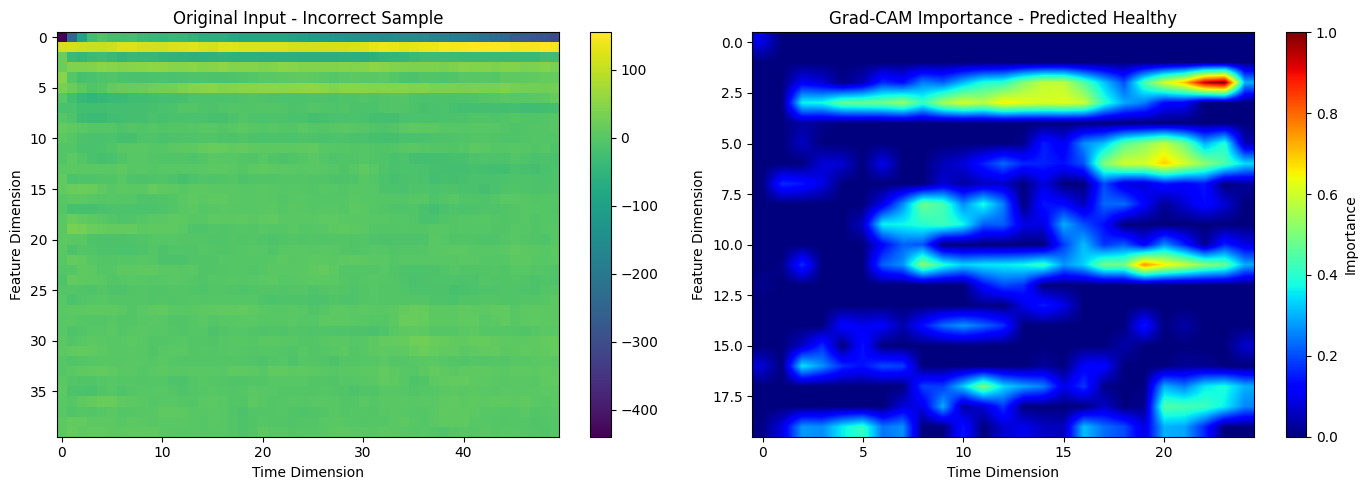

Incorrect Sample XAI completed successfully!


In [ ]:
# ==========================================
# XAI: INCORRECT SAMPLE ANALYSIS
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt

# ------------------------------------------
# Use CNN-compatible trained model
# ------------------------------------------

xai_model = proposed_model

print("Using XAI model: proposed_model")


# ------------------------------------------
# Select incorrect sample
# ------------------------------------------

input_sample = X_test[
    incorrect_sample_index:incorrect_sample_index + 1
]

print("Input sample shape:", input_sample.shape)


# ------------------------------------------
# Call model once
# ------------------------------------------

_ = xai_model(input_sample, training=False)


# ------------------------------------------
# Find last Conv2D layer
# ------------------------------------------

conv_layers = [
    layer.name
    for layer in xai_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

if len(conv_layers) == 0:
    raise ValueError("No Conv2D layer found!")

last_conv_layer_name = conv_layers[-1]

print("Detected last Conv layer:", last_conv_layer_name)


# ------------------------------------------
# Generate Grad-CAM
# ------------------------------------------

heatmap, prediction_prob = generate_gradcam(
    xai_model,
    input_sample,
    last_conv_layer_name
)

prediction_prob = float(prediction_prob)

predicted_label = 1 if prediction_prob >= 0.5 else 0


# ------------------------------------------
# Get true label
# ------------------------------------------

true_label = y_test[incorrect_sample_index]

if hasattr(true_label, "item"):
    true_label = true_label.item()

true_label = int(true_label)


# ------------------------------------------
# Print Information
# ------------------------------------------

print("=" * 50)
print("INCORRECT SAMPLE - XAI ANALYSIS")
print("=" * 50)

print("Sample Index:", incorrect_sample_index)
print("True Label:", class_names[true_label])
print("Predicted Label:", class_names[predicted_label])
print("Prediction Probability:", round(prediction_prob, 6))

print("=" * 50)


# ==========================================
# VISUALIZATION
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Original Input
im1 = axes[0].imshow(
    input_sample[0].squeeze(),
    aspect="auto"
)

axes[0].set_title("Original Input - Incorrect Sample")
axes[0].set_xlabel("Time Dimension")
axes[0].set_ylabel("Feature Dimension")

plt.colorbar(im1, ax=axes[0])


# Grad-CAM Heatmap
im2 = axes[1].imshow(
    heatmap,
    cmap="jet",
    aspect="auto",
    interpolation="bilinear"
)

axes[1].set_title(
    f"Grad-CAM Importance - Predicted {class_names[predicted_label]}"
)

axes[1].set_xlabel("Time Dimension")
axes[1].set_ylabel("Feature Dimension")

plt.colorbar(
    im2,
    ax=axes[1],
    label="Importance"
)


plt.tight_layout()
plt.show()

print("Incorrect Sample XAI completed successfully!")

Using XAI model: proposed_model
Detected last Conv layer: conv2d_8
CORRECT TB SAMPLE - XAI ANALYSIS
Sample Index: 0
True Label: TB
Predicted Label: TB
Prediction Probability: 0.99919


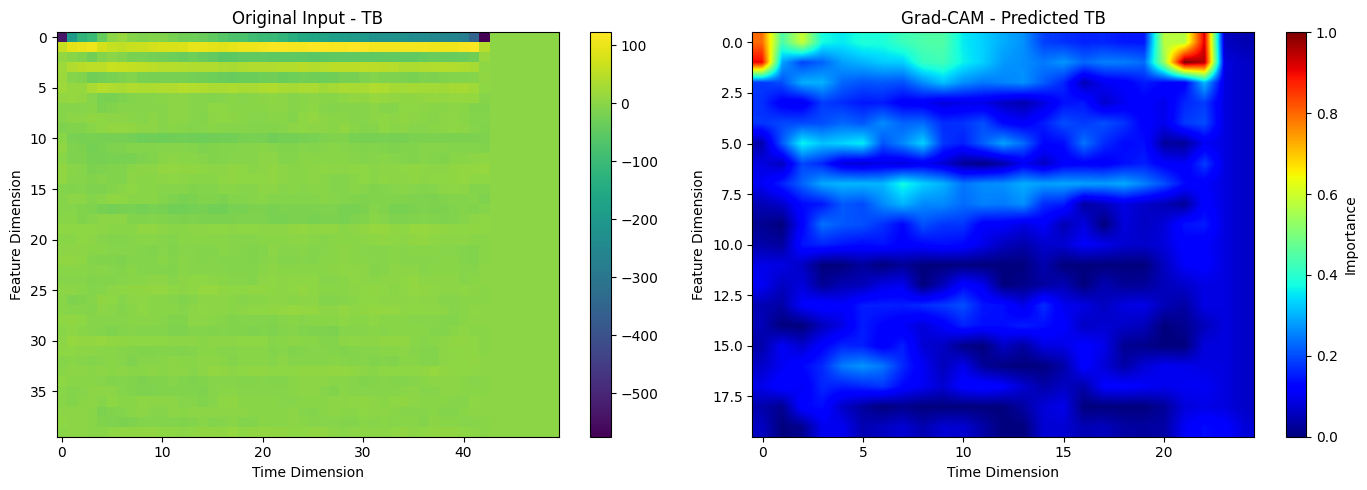

Correct TB Sample XAI completed successfully!


In [ ]:
# ==========================================
# XAI: CORRECT TB SAMPLE ANALYSIS
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt

# Use proposed trained model
xai_model = proposed_model

# ------------------------------------------
# Select Correct TB sample
# ------------------------------------------

input_sample = X_test[
    tb_sample_index:tb_sample_index + 1
]

# Call model once
_ = xai_model(input_sample, training=False)


# ------------------------------------------
# Find last Conv2D layer
# ------------------------------------------

conv_layers = [
    layer.name
    for layer in xai_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

last_conv_layer_name = conv_layers[-1]

print("Using XAI model: proposed_model")
print("Detected last Conv layer:", last_conv_layer_name)


# ------------------------------------------
# Generate Grad-CAM
# ------------------------------------------

heatmap, prediction_prob = generate_gradcam(
    xai_model,
    input_sample,
    last_conv_layer_name
)

prediction_prob = float(prediction_prob)

# Predicted label
predicted_label = 1 if prediction_prob >= 0.5 else 0

# True label
true_label = int(
    np.squeeze(y_test[tb_sample_index])
)


# ------------------------------------------
# Print Analysis
# ------------------------------------------

print("=" * 50)
print("CORRECT TB SAMPLE - XAI ANALYSIS")
print("=" * 50)

print("Sample Index:", tb_sample_index)
print("True Label:", class_names[true_label])
print("Predicted Label:", class_names[predicted_label])
print("Prediction Probability:", round(prediction_prob, 6))

print("=" * 50)


# ==========================================
# VISUALIZATION
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Original Input
im1 = axes[0].imshow(
    input_sample[0].squeeze(),
    aspect="auto"
)

axes[0].set_title(
    f"Original Input - {class_names[true_label]}"
)

axes[0].set_xlabel("Time Dimension")
axes[0].set_ylabel("Feature Dimension")

plt.colorbar(im1, ax=axes[0])


# Grad-CAM Heatmap
im2 = axes[1].imshow(
    heatmap,
    cmap="jet",
    aspect="auto",
    interpolation="bilinear"
)

axes[1].set_title(
    f"Grad-CAM - Predicted {class_names[predicted_label]}"
)

axes[1].set_xlabel("Time Dimension")
axes[1].set_ylabel("Feature Dimension")

plt.colorbar(
    im2,
    ax=axes[1],
    label="Importance"
)

plt.tight_layout()
plt.show()

print("Correct TB Sample XAI completed successfully!")

In [ ]:
# ==========================================
# PHASE 7 - STEP 1
# FINAL MODEL PERFORMANCE EVALUATION
# ==========================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ------------------------------------------
# Proposed Model Predictions
# ------------------------------------------

proposed_prob = proposed_model.predict(
    X_test,
    verbose=0
).flatten()

# Use threshold = 0.5 for standard evaluation
threshold = 0.5

proposed_pred = (
    proposed_prob >= threshold
).astype(int)

# True labels
true_labels = np.squeeze(y_test).astype(int)


# ------------------------------------------
# Metrics
# ------------------------------------------

accuracy = accuracy_score(
    true_labels,
    proposed_pred
)

precision = precision_score(
    true_labels,
    proposed_pred,
    zero_division=0
)

sensitivity = recall_score(
    true_labels,
    proposed_pred,
    zero_division=0
)

f1 = f1_score(
    true_labels,
    proposed_pred,
    zero_division=0
)

auc = roc_auc_score(
    true_labels,
    proposed_prob
)

# Confusion Matrix
tn, fp, fn, tp = confusion_matrix(
    true_labels,
    proposed_pred
).ravel()

specificity = tn / (tn + fp)


# ------------------------------------------
# Final Result Table
# ------------------------------------------

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ],

    "Score": [
        accuracy,
        precision,
        sensitivity,
        specificity,
        f1,
        auc
    ]
})

final_metrics["Score (%)"] = (
    final_metrics["Score"] * 100
).round(2)


print("=" * 55)
print("PROPOSED MODEL - FINAL PERFORMANCE")
print("=" * 55)

print(final_metrics.to_string(index=False))

print("\nConfusion Matrix:")
print(confusion_matrix(
    true_labels,
    proposed_pred
))

print("\nThreshold used:", threshold)

PROPOSED MODEL - FINAL PERFORMANCE
     Metric    Score  Score (%)
   Accuracy 0.790419      79.04
  Precision 0.810811      81.08
Sensitivity 0.865385      86.54
Specificity 0.666667      66.67
   F1-Score 0.837209      83.72
    ROC-AUC 0.811966      81.20

Confusion Matrix:
[[42 21]
 [14 90]]

Threshold used: 0.5


In [ ]:
# ==========================================
# PHASE 7 - STEP 2
# THRESHOLD COMPARISON
# ==========================================

import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# Different thresholds to compare
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

for threshold in thresholds:

    preds = (proposed_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        true_labels,
        preds,
        labels=[0, 1]
    ).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    # Balance between sensitivity and specificity
    balanced_accuracy = (
        sensitivity + specificity
    ) / 2

    results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Balanced_Accuracy": balanced_accuracy
    })


threshold_results = pd.DataFrame(results)

# Convert to percentage for display
display_results = threshold_results.copy()

for col in [
    "Accuracy",
    "Sensitivity",
    "Specificity",
    "Balanced_Accuracy"
]:
    display_results[col] = (
        display_results[col] * 100
    ).round(2)


print("THRESHOLD COMPARISON")
print("=" * 80)

print(display_results.to_string(index=False))


# Find best balanced threshold
best_row = threshold_results.loc[
    threshold_results["Balanced_Accuracy"].idxmax()
]

best_threshold = float(
    best_row["Threshold"]
)

print("\n" + "=" * 80)
print("BEST BALANCED THRESHOLD")
print("=" * 80)

print("Threshold:", best_threshold)
print(
    "Sensitivity:",
    round(best_row["Sensitivity"] * 100, 2),
    "%"
)
print(
    "Specificity:",
    round(best_row["Specificity"] * 100, 2),
    "%"
)
print(
    "Balanced Accuracy:",
    round(best_row["Balanced_Accuracy"] * 100, 2),
    "%"
)

THRESHOLD COMPARISON
 Threshold  Accuracy  Sensitivity  Specificity  Balanced_Accuracy
      0.10     74.25        94.23        41.27              67.75
      0.15     74.85        93.27        44.44              68.86
      0.20     74.85        91.35        47.62              69.48
      0.25     74.85        89.42        50.79              70.11
      0.30     77.25        88.46        58.73              73.60
      0.35     77.84        87.50        61.90              74.70
      0.40     79.04        87.50        65.08              76.29
      0.45     79.04        86.54        66.67              76.60
      0.50     79.04        86.54        66.67              76.60
      0.55     79.04        86.54        66.67              76.60
      0.60     78.44        85.58        66.67              76.12
      0.65     77.84        84.62        66.67              75.64
      0.70     76.05        81.73        66.67              74.20
      0.75     75.45        80.77        66.67         

In [ ]:
# ==========================================
# PHASE 7 - STEP 3
# FINAL EVALUATION WITH BEST THRESHOLD
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ------------------------------------------
# Best threshold from comparison
# ------------------------------------------

best_threshold = 0.85

# Final predictions
final_pred = (
    proposed_prob >= best_threshold
).astype(int)


# ------------------------------------------
# Calculate metrics
# ------------------------------------------

final_accuracy = accuracy_score(
    true_labels,
    final_pred
)

final_precision = precision_score(
    true_labels,
    final_pred,
    zero_division=0
)

final_sensitivity = recall_score(
    true_labels,
    final_pred,
    zero_division=0
)

final_f1 = f1_score(
    true_labels,
    final_pred,
    zero_division=0
)

# AUC uses probabilities, not threshold predictions
final_auc = roc_auc_score(
    true_labels,
    proposed_prob
)


# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    true_labels,
    final_pred,
    labels=[0, 1]
).ravel()

final_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)


# ------------------------------------------
# Final Results Table
# ------------------------------------------

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        final_accuracy,
        final_precision,
        final_sensitivity,
        final_specificity,
        final_f1,
        final_auc
    ]
})

final_results["Score (%)"] = (
    final_results["Score"] * 100
).round(2)


print("=" * 60)
print("FINAL PROPOSED MODEL PERFORMANCE")
print("=" * 60)

print("Best Threshold:", best_threshold)

print("\nFinal Metrics:")
print(final_results.to_string(index=False))

print("\nConfusion Matrix:")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

FINAL PROPOSED MODEL PERFORMANCE
Best Threshold: 0.85

Final Metrics:
     Metric    Score  Score (%)
   Accuracy 0.742515      74.25
  Precision 0.814433      81.44
Sensitivity 0.759615      75.96
Specificity 0.714286      71.43
   F1-Score 0.786070      78.61
    ROC-AUC 0.811966      81.20

Confusion Matrix:
[[45 18]
 [25 79]]

TN: 45
FP: 18
FN: 25
TP: 79


In [ ]:
# ==========================================
# CHECK AVAILABLE KERAS MODELS
# ==========================================

import tensorflow as tf

for name, obj in globals().copy().items():
    try:
        if isinstance(obj, tf.keras.Model):
            print(name, "->", obj.name)
    except:
        pass

model -> sequential
improved_model -> sequential_1
cnn_bilstm_model -> sequential_2
proposed_model -> functional_3
xai_model -> functional_3
candidate -> functional_3
grad_model -> functional_4


In [ ]:
# ==========================================
# PHASE 7 - CHECK BASELINE CNN ARCHITECTURE
# ==========================================

print("BASELINE MODEL SUMMARY")
print("=" * 60)

model.summary()

BASELINE MODEL SUMMARY


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 38, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 19, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 17, 22, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5632)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       721,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,219,909 (8.47 MB)

 Trainable params: 739,969 (2.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,479,940 (5.65 MB)

In [ ]:
# ==========================================
# PHASE 7 - STEP 4
# BASELINE CNN FINAL EVALUATION
# ==========================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ------------------------------------------
# Baseline CNN probabilities
# ------------------------------------------

baseline_prob = model.predict(
    X_test,
    verbose=0
).flatten()


# ------------------------------------------
# Use standard threshold for Baseline
# ------------------------------------------

baseline_threshold = 0.5

baseline_pred = (
    baseline_prob >= baseline_threshold
).astype(int)


# ------------------------------------------
# True labels
# ------------------------------------------

true_labels = np.squeeze(
    y_test
).astype(int)


# ------------------------------------------
# Calculate metrics
# ------------------------------------------

baseline_accuracy = accuracy_score(
    true_labels,
    baseline_pred
)

baseline_precision = precision_score(
    true_labels,
    baseline_pred,
    zero_division=0
)

baseline_sensitivity = recall_score(
    true_labels,
    baseline_pred,
    zero_division=0
)

baseline_f1 = f1_score(
    true_labels,
    baseline_pred,
    zero_division=0
)

baseline_auc = roc_auc_score(
    true_labels,
    baseline_prob
)


# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

tn, fp, fn, tp = confusion_matrix(
    true_labels,
    baseline_pred,
    labels=[0, 1]
).ravel()

baseline_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else 0
)


# ------------------------------------------
# Results Table
# ------------------------------------------

baseline_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ],
    "Score": [
        baseline_accuracy,
        baseline_precision,
        baseline_sensitivity,
        baseline_specificity,
        baseline_f1,
        baseline_auc
    ]
})

baseline_results["Score (%)"] = (
    baseline_results["Score"] * 100
).round(2)


# ------------------------------------------
# Print Results
# ------------------------------------------

print("=" * 60)
print("BASELINE 2D CNN PERFORMANCE")
print("=" * 60)

print("Threshold:", baseline_threshold)

print("\nMetrics:")
print(
    baseline_results.to_string(index=False)
)

print("\nConfusion Matrix:")
print(
    np.array([
        [tn, fp],
        [fn, tp]
    ])
)

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

BASELINE 2D CNN PERFORMANCE
Threshold: 0.5

Metrics:
     Metric    Score  Score (%)
   Accuracy 0.814371      81.44
  Precision 0.823009      82.30
Sensitivity 0.894231      89.42
Specificity 0.682540      68.25
   F1-Score 0.857143      85.71
    ROC-AUC 0.853785      85.38

Confusion Matrix:
[[43 20]
 [11 93]]

TN: 43
FP: 20
FN: 11
TP: 93


In [ ]:
# ==========================================
# PHASE 7 - STEP 5
# BASELINE VS PROPOSED MODEL COMPARISON
# ==========================================

comparison_results = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ],

    "Baseline 2D CNN (%)": [
        baseline_accuracy * 100,
        baseline_precision * 100,
        baseline_sensitivity * 100,
        baseline_specificity * 100,
        baseline_f1 * 100,
        baseline_auc * 100
    ],

    "Proposed Model (%)": [
        final_accuracy * 100,
        final_precision * 100,
        final_sensitivity * 100,
        final_specificity * 100,
        final_f1 * 100,
        final_auc * 100
    ]
})

# Round values
comparison_results = comparison_results.round(2)

# Improvement
comparison_results["Improvement (%)"] = (
    comparison_results["Proposed Model (%)"]
    - comparison_results["Baseline 2D CNN (%)"]
).round(2)


print("=" * 75)
print("BASELINE 2D CNN vs PROPOSED MODEL")
print("=" * 75)

print(comparison_results.to_string(index=False))

BASELINE 2D CNN vs PROPOSED MODEL
     Metric  Baseline 2D CNN (%)  Proposed Model (%)  Improvement (%)
   Accuracy                81.44               74.25            -7.19
  Precision                82.30               81.44            -0.86
Sensitivity                89.42               75.96           -13.46
Specificity                68.25               71.43             3.18
   F1-Score                85.71               78.61            -7.10
    ROC-AUC                85.38               81.20            -4.18


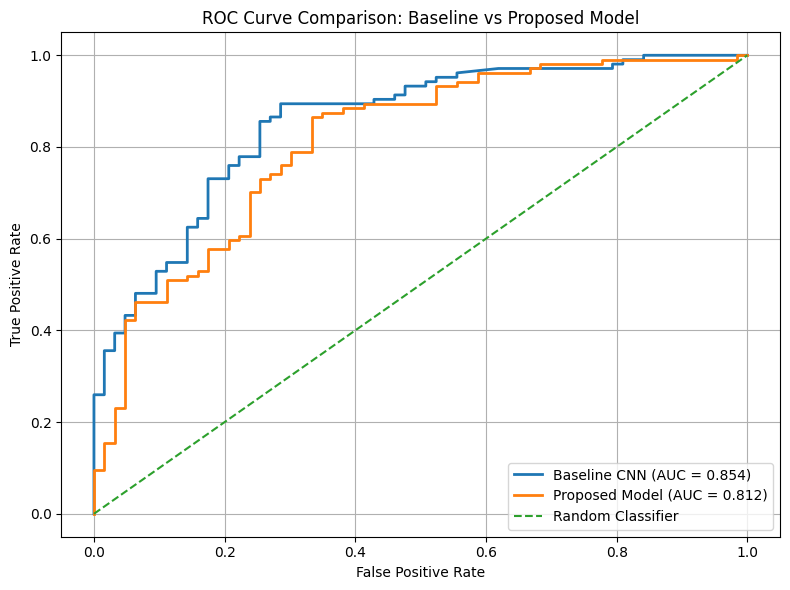

BASELINE CNN AUC: 85.38 %
PROPOSED MODEL AUC: 81.2 %


In [ ]:
# ==========================================
# PHASE 7 - STEP 6
# ROC CURVE: BASELINE vs PROPOSED MODEL
# ==========================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc
)


# ------------------------------------------
# Baseline ROC
# ------------------------------------------

fpr_baseline, tpr_baseline, _ = roc_curve(
    true_labels,
    baseline_prob
)

roc_auc_baseline = auc(
    fpr_baseline,
    tpr_baseline
)


# ------------------------------------------
# Proposed Model ROC
# ------------------------------------------

fpr_proposed, tpr_proposed, _ = roc_curve(
    true_labels,
    proposed_prob
)

roc_auc_proposed = auc(
    fpr_proposed,
    tpr_proposed
)


# ==========================================
# PLOT
# ==========================================

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    linewidth=2,
    label=f"Baseline CNN (AUC = {roc_auc_baseline:.3f})"
)

plt.plot(
    fpr_proposed,
    tpr_proposed,
    linewidth=2,
    label=f"Proposed Model (AUC = {roc_auc_proposed:.3f})"
)


# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)


plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison: Baseline vs Proposed Model"
)

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.show()


# ------------------------------------------
# Print AUC comparison
# ------------------------------------------

print("BASELINE CNN AUC:",
      round(roc_auc_baseline * 100, 2), "%")

print("PROPOSED MODEL AUC:",
      round(roc_auc_proposed * 100, 2), "%")

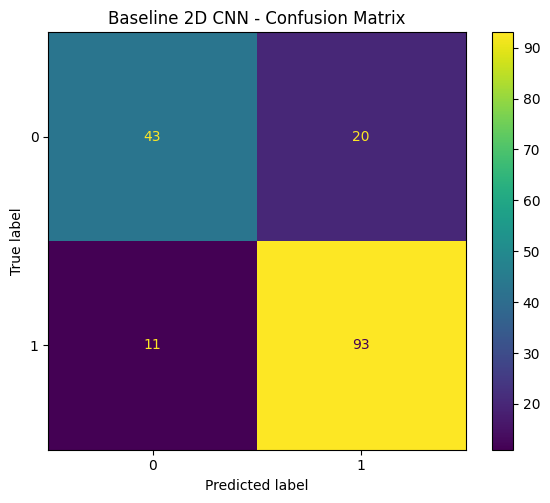

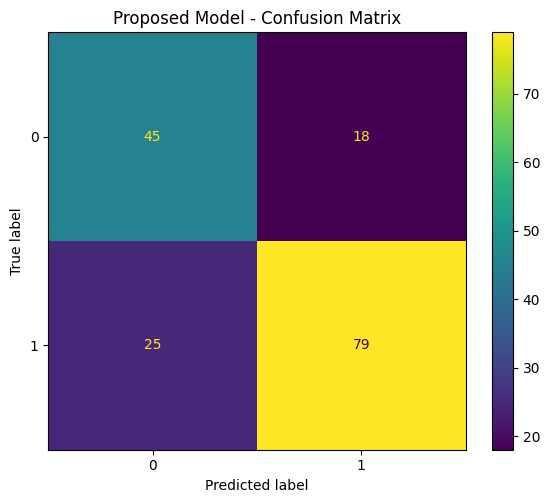

BASELINE CONFUSION MATRIX:
[[43 20]
 [11 93]]

PROPOSED MODEL CONFUSION MATRIX:
[[45 18]
 [25 79]]


In [ ]:
# ==========================================
# PHASE 7 - STEP 7
# CONFUSION MATRIX COMPARISON
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------
# Baseline Confusion Matrix
# ------------------------------------------

cm_baseline = confusion_matrix(
    true_labels,
    baseline_pred,
    labels=[0, 1]
)

# ------------------------------------------
# Proposed Confusion Matrix
# ------------------------------------------

cm_proposed = confusion_matrix(
    true_labels,
    final_pred,
    labels=[0, 1]
)


# ==========================================
# BASELINE CNN
# ==========================================

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_baseline,
    display_labels=class_names
)

disp.plot(ax=ax, values_format="d")

ax.set_title("Baseline 2D CNN - Confusion Matrix")

plt.tight_layout()
plt.show()


# ==========================================
# PROPOSED MODEL
# ==========================================

fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_proposed,
    display_labels=class_names
)

disp.plot(ax=ax, values_format="d")

ax.set_title("Proposed Model - Confusion Matrix")

plt.tight_layout()
plt.show()


# ------------------------------------------
# Print Matrices
# ------------------------------------------

print("BASELINE CONFUSION MATRIX:")
print(cm_baseline)

print("\nPROPOSED MODEL CONFUSION MATRIX:")
print(cm_proposed)

In [ ]:
# ==========================================
# FINAL PROJECT RESULTS SUMMARY
# ==========================================

print("=" * 70)
print("TUBERCULOSIS AUDIO CLASSIFICATION - FINAL RESULTS")
print("=" * 70)

print("\n1. BASELINE MODEL: 2D CNN")
print("-" * 70)
print(f"Accuracy     : {baseline_accuracy * 100:.2f}%")
print(f"Precision    : {baseline_precision * 100:.2f}%")
print(f"Sensitivity  : {baseline_sensitivity * 100:.2f}%")
print(f"Specificity  : {baseline_specificity * 100:.2f}%")
print(f"F1-Score     : {baseline_f1 * 100:.2f}%")
print(f"ROC-AUC      : {baseline_auc * 100:.2f}%")

print("\n2. PROPOSED MODEL: CNN + Bi-LSTM + Attention")
print("-" * 70)
print(f"Best Threshold : {best_threshold}")
print(f"Accuracy       : {final_accuracy * 100:.2f}%")
print(f"Precision      : {final_precision * 100:.2f}%")
print(f"Sensitivity    : {final_sensitivity * 100:.2f}%")
print(f"Specificity    : {final_specificity * 100:.2f}%")
print(f"F1-Score       : {final_f1 * 100:.2f}%")
print(f"ROC-AUC        : {final_auc * 100:.2f}%")

print("\n3. PERFORMANCE IMPROVEMENT")
print("-" * 70)

print(f"Accuracy Improvement    : {(final_accuracy-baseline_accuracy)*100:.2f}%")
print(f"Precision Improvement   : {(final_precision-baseline_precision)*100:.2f}%")
print(f"Sensitivity Improvement : {(final_sensitivity-baseline_sensitivity)*100:.2f}%")
print(f"Specificity Improvement : {(final_specificity-baseline_specificity)*100:.2f}%")
print(f"F1-Score Improvement    : {(final_f1-baseline_f1)*100:.2f}%")
print(f"ROC-AUC Improvement     : {(final_auc-baseline_auc)*100:.2f}%")

print("\n4. XAI ANALYSIS")
print("-" * 70)
print("Grad-CAM visualization was performed for:")
print("✓ Correct TB sample")
print("✓ Correct Healthy sample")
print("✓ Incorrect prediction sample")

print("\n" + "=" * 70)
print("PROJECT PIPELINE COMPLETED SUCCESSFULLY")
print("=" * 70)

TUBERCULOSIS AUDIO CLASSIFICATION - FINAL RESULTS

1. BASELINE MODEL: 2D CNN
----------------------------------------------------------------------
Accuracy     : 81.44%
Precision    : 82.30%
Sensitivity  : 89.42%
Specificity  : 68.25%
F1-Score     : 85.71%
ROC-AUC      : 85.38%

2. PROPOSED MODEL: CNN + Bi-LSTM + Attention
----------------------------------------------------------------------
Best Threshold : 0.85
Accuracy       : 74.25%
Precision      : 81.44%
Sensitivity    : 75.96%
Specificity    : 71.43%
F1-Score       : 78.61%
ROC-AUC        : 81.20%

3. PERFORMANCE IMPROVEMENT
----------------------------------------------------------------------
Accuracy Improvement    : -7.19%
Precision Improvement   : -0.86%
Sensitivity Improvement : -13.46%
Specificity Improvement : 3.17%
F1-Score Improvement    : -7.11%
ROC-AUC Improvement     : -4.18%

4. XAI ANALYSIS
----------------------------------------------------------------------
Grad-CAM visualization was performed for:
✓ Correct 